# Wine Quality Prediction
## AAI-500: Probability and Statistics for Artificial Intelligence
### Group 1 | University of San Diego

| Team Member | Sections | Role |
|---|---|---|
| **Tena Alshaikhli** | 1, 4, 5, 8| Team Lead |
| **Roopleen Kaur** | 2, 3, 9 | Data Cleaning, EDA, Model Analysis |
| **Timothy Hays** | 6, 7, 10 | Hypothesis Testing, Model Selection, Conclusion |

**Dataset:** UCI Wine Quality Dataset (Cortez et al., 2009)

**GitHub:** https://github.com/Denaalshaikhli/Wine-Quality-Prediction

**Style Guide:** PEP 8 (https://pep8.org)

## Section 1: Introduction
**Author: Tena Alshaikhli**

Wine quality assessment has traditionally relied on sensory evaluation by trained human experts, a process that is expensive, time-consuming, and inherently subjective. This project addresses the following business question:

> **Can physicochemical properties of wine, measurable through standard laboratory testing, reliably predict whether a wine will be rated as good or poor quality?**

The dataset used is the UCI Wine Quality Dataset (Cortez et al., 2009), combining red and white Vinho Verde wine samples for a total of 6,497 observations and 11 physicochemical input variables. Each wine was evaluated by at least three sensory experts on a scale from 0 (very bad) to 10 (excellent). The median score was used as the quality rating.

This analysis follows the statistical framework developed across all seven modules of AAI-500, beginning with descriptive statistics and data visualization (Module 1), proceeding through probability distributions and Bayesian reasoning (Modules 2 and 3), confidence intervals and hypothesis testing (Module 4), Bayesian Networks (Module 5), Generalized Linear Models (Module 6), and concluding with classification (Module 7). Each analytical decision is statistically grounded and explainable to a non-technical audience.

**APA References**

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems, 47*(4), 547-553. https://doi.org/10.1016/j.dss.2009.05.016

Agresti, A., & Kateri, M. (2022). *Foundations of statistics for data scientists: With R and Python*. CRC Press.

UCI Machine Learning Repository. (2009). *Wine quality dataset*. https://archive.ics.uci.edu/dataset/186/wine+quality

## Section 2: Data Cleaning and Preparation
**Author: Roopleen Kaur**

*(Module 1: Descriptive Statistics and Data Collection | Module 6: Generalized Linear Models | Module 7: Classification, Clustering, and Linear Algebra)*

#### **Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests**

In [109]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, pearsonr, chi2_contingency
import statsmodels.api as sm

# Red wine — UCI Wine Quality dataset: https://archive.ics.uci.edu/dataset/186/wine+quality
RED_WINE_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "wine-quality/winequality-red.csv"
)
df1 = pd.read_csv(RED_WINE_URL, sep=";")
df1.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [110]:
# White wine — same UCI repository
WHITE_WINE_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "wine-quality/winequality-white.csv"
)
df2 = pd.read_csv(WHITE_WINE_URL, sep=";")
df2.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


**Data Exploration:**

In [111]:
#checking dtypes, null values and columns for red wine dataset
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [112]:
#checking dtypes, null values and columns for white wine dataset
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


**Insights:** No null values are present in any of the datasets and the target variable is Quality
####**Exploring Target Variable:**

In [113]:
#Checking quality target variable for red wine dataset
df1['quality'].value_counts().sort_values()

,count
quality,
3,10
8,18
4,53
7,199
6,638
5,681


In [114]:
#Checking quality target variable for white wine dataset
df2['quality'].value_counts().sort_values()

,count
quality,
9,5
3,20
4,163
8,175
7,880
5,1457
6,2198


**Descriptive Statistics:**

In [115]:
#checking the 5 number summary for red wine dataset
df1.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


**Red Wine Dataset:**
1. The red wine dataset shows moderate variability across most features. The average fixed acidity is 8.32, which is higher compared to white wine, indicating that red wines are generally more acidic. Volatile acidity has a mean of 0.53, showing the presence of higher volatile compounds that may influence taste quality.
2. Residual sugar levels are relatively low (mean = 2.54), suggesting that red wines are generally less sweet compared to white wines. Chlorides also remain low (mean = 0.087), although the maximum value (0.611) indicates the presence of some outliers.
3. Sulfur dioxide levels show variability, with free sulfur dioxide averaging 15.87 and total sulfur dioxide averaging 46.46, indicating differences in preservation levels across samples. Density values are tightly clustered around 0.9967, showing low variation.
4. The pH values range from 2.74 to 4.01, indicating moderate acidity variation. Alcohol content has a mean of 10.42, with values ranging from 8.4 to 14.9. The quality ratings range from 3 to 8, with most observations concentrated around mid-range values.


In [116]:
#checking the 5 number summary for white wine dataset
df2.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


**White Wine Dataset:**

1. The white wine dataset shows distinct distribution patterns compared to red wine. The average fixed acidity is 6.85, which is lower than red wine, indicating that white wines are generally less acidic.
2. Volatile acidity is also lower (mean = 0.28), suggesting fewer volatile compounds. However, residual sugar is significantly higher (mean = 6.39), with a maximum value of 65.8, indicating that white wines are generally sweeter and more variable in sugar content.
3. Chlorides remain low (mean = 0.046), and density is tightly clustered around 0.994, showing consistent physical properties across samples.
4. Sulfur dioxide levels are much higher in white wine compared to red wine, with free sulfur dioxide averaging 35.31 and total sulfur dioxide averaging 138.36. This indicates stronger preservation requirements in white wines.
Alcohol content is similar to red wine, with a mean of 10.51 and a range from 8.0 to 14.2. pH values range between 2.72 and 3.82, showing moderate acidity variation.


**Key Comparative Insights:**
A comparison of both datasets reveals several important differences:
1. Red wines have higher fixed acidity compared to white wines.
2. White wines contain significantly higher residual sugar, making them generally sweeter.
3. White wines also have much higher sulfur dioxide levels, indicating stronger preservation.
4. Alcohol content is similar across both datasets, with only slight differences in variation.
5. Both datasets show similar quality distribution patterns, with most wines rated in the mid-range.
6. Several features such as residual sugar and sulfur dioxide show evidence of skewness and outliers, particularly in white wine.


**In the following steps, we dropped duplicates so as no bias is introduced in the models as wine datasets usually have duplicates**

In [117]:
#Checking the number of duplicate values in red wine dataset
df1.duplicated().sum()


np.int64(240)

In [118]:
#Dropping duplicates
red = df1.drop_duplicates()

In [119]:
#Double Checking
red.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   residual sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free sulfur dioxide   1359 non-null   float64
 6   total sulfur dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  quality               1359 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 138.0 KB


In [120]:
#Checking the number of duplicates in white wine dataset
df2.duplicated().sum()

np.int64(937)

In [121]:
#Dropping duplicates
white = df2.drop_duplicates()

In [122]:
#Double checking
white.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3961 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         3961 non-null   float64
 1   volatile acidity      3961 non-null   float64
 2   citric acid           3961 non-null   float64
 3   residual sugar        3961 non-null   float64
 4   chlorides             3961 non-null   float64
 5   free sulfur dioxide   3961 non-null   float64
 6   total sulfur dioxide  3961 non-null   float64
 7   density               3961 non-null   float64
 8   pH                    3961 non-null   float64
 9   sulphates             3961 non-null   float64
 10  alcohol               3961 non-null   float64
 11  quality               3961 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 402.3 KB


####**Feature Engineering:**
red wine = 0
white wine  = 1

In [123]:
#Creating New Column Wine_type to classify red or white wine
red = red.copy()
white = white.copy()
red["wine_type"] = 0
white["wine_type"] = 1

####**Combining the Datasets:**

In [124]:
#Concatenating both the datasets row-wise
df = pd.concat([red, white], axis=0).reset_index(drop=True)
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0
5,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,0
6,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,0
7,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,0
8,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,0
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,0


In [125]:
#Determining the distribution of wine types in our final dataset
df["wine_type"].value_counts()

,count
wine_type,
1,3961
0,1359


**Shuffling the data to avoid order bias**


In [126]:
#Shuffling the data to avoid order bias
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,5.3,0.32,0.12,6.6,0.043,22.0,141.0,0.99370,3.36,0.60,10.4,6,1
1,6.4,0.30,0.27,4.4,0.055,17.0,135.0,0.99250,3.23,0.44,12.2,6,1
2,6.5,0.22,0.32,2.2,0.028,36.0,92.0,0.99076,3.27,0.59,11.9,7,1
3,8.0,0.24,0.48,6.8,0.047,13.0,134.0,0.99616,3.23,0.70,10.0,5,1
4,8.9,0.29,0.35,1.9,0.067,25.0,57.0,0.99700,3.18,1.36,10.3,6,0


In [127]:
# Create Good/Poor subsets directly from the original quality score
good = df.loc[df["quality"] >= 6].copy()
poor = df.loc[df["quality"] < 6].copy()

print(f"Good wines: {len(good)}")
print(f"Poor wines: {len(poor)}")

Good wines: 3332
Poor wines: 1988


## Section 3: Exploratory Data Analysis
**Author: Roopleen Kaur**

###**Countplot of Red and White wine types**

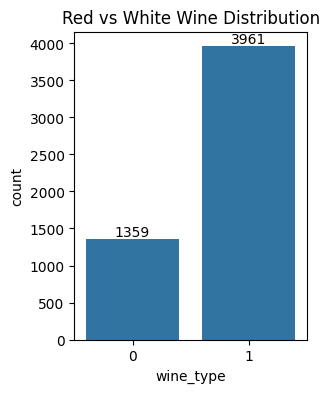

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3,4))

ax = sns.countplot(x="wine_type", data=df)

plt.title("Red vs White Wine Distribution")
# add numbers on top of bars
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

So we now have, 1359 red wine sample data and 3961 white wine data in our dataset.

###**Distribution of Wine Quality by Wine Type**


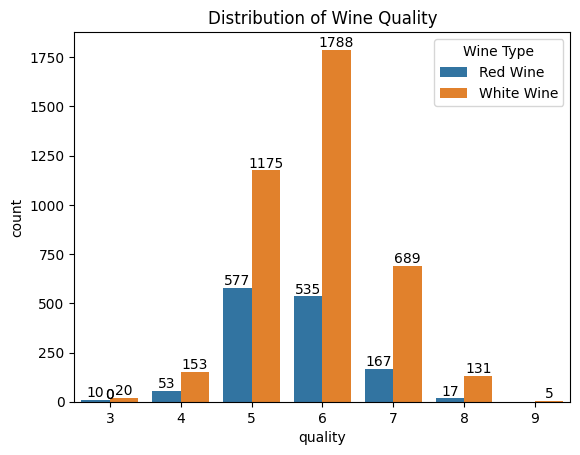

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the distribution of wine quality
ax = sns.countplot(x="quality", data=df, hue ="wine_type")

plt.title("Distribution of Wine Quality")

# add numbers on top of bars
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

#Handling labels for this Plot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Red Wine", "White Wine"], title="Wine Type")
plt.show()

**Insights:**

1. The distribution of wine quality ratings indicates that most wines are concentrated in the mid-quality categories, particularly scores of 5 and 6. For red wines, quality scores of 5 and 6 are the most common, with 577 and 535 observations, respectively. Similarly, white wines are predominantly rated 5 and 6, with 1,175 and 1,788 observations, respectively.

2. White wines outnumber red wines across all quality categories due to their larger representation in the dataset. Low-quality wines (ratings 3 and 4) are relatively uncommon, while higher-quality wines (ratings 7 and above) occur less frequently than the mid-range categories. The highest quality score observed for red wines is 8, with only 17 samples receiving this rating. In contrast, white wines include a small number of quality 9 samples, with only five observations in this category.

3. Overall, the distribution of the target variable is imbalanced, with the majority of wines receiving quality ratings of 5 or 6. This indicates that average-quality wines dominate the dataset, while very low- and very high-quality wines are underrepresented. The limited number of samples at the extreme quality levels may make it more challenging for predictive models to accurately identify exceptionally poor or exceptionally high-quality wines.


####**Outlier Count:**

In [130]:
outlier_counts = {}

for col in df.select_dtypes(include='number').columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_counts[col] = len(outliers)

outlier_df = (
    pd.DataFrame(
        outlier_counts.items(),
        columns=['Feature','Outlier Count']
    )
    .sort_values('Outlier Count', ascending=False)
)

outlier_df

,Feature,Outlier Count
0,fixed acidity,304
1,volatile acidity,279
4,chlorides,237
11,quality,183
9,sulphates,163
2,citric acid,143
3,residual sugar,141
8,pH,49
5,free sulfur dioxide,44
6,total sulfur dioxide,10


Although several features contained outliers, they were retained because they appear to represent valid wine measurements rather than erroneous observations. Preserving these values helps maintain the natural variability of the dataset and ensures that the analysis reflects real-world wine characteristics.

###**Histogram (Distribution Plot) Analysis**

Histogram (distribution plot) analysis was used to examine the spread, shape, and skewness of all numerical features in the wine dataset.

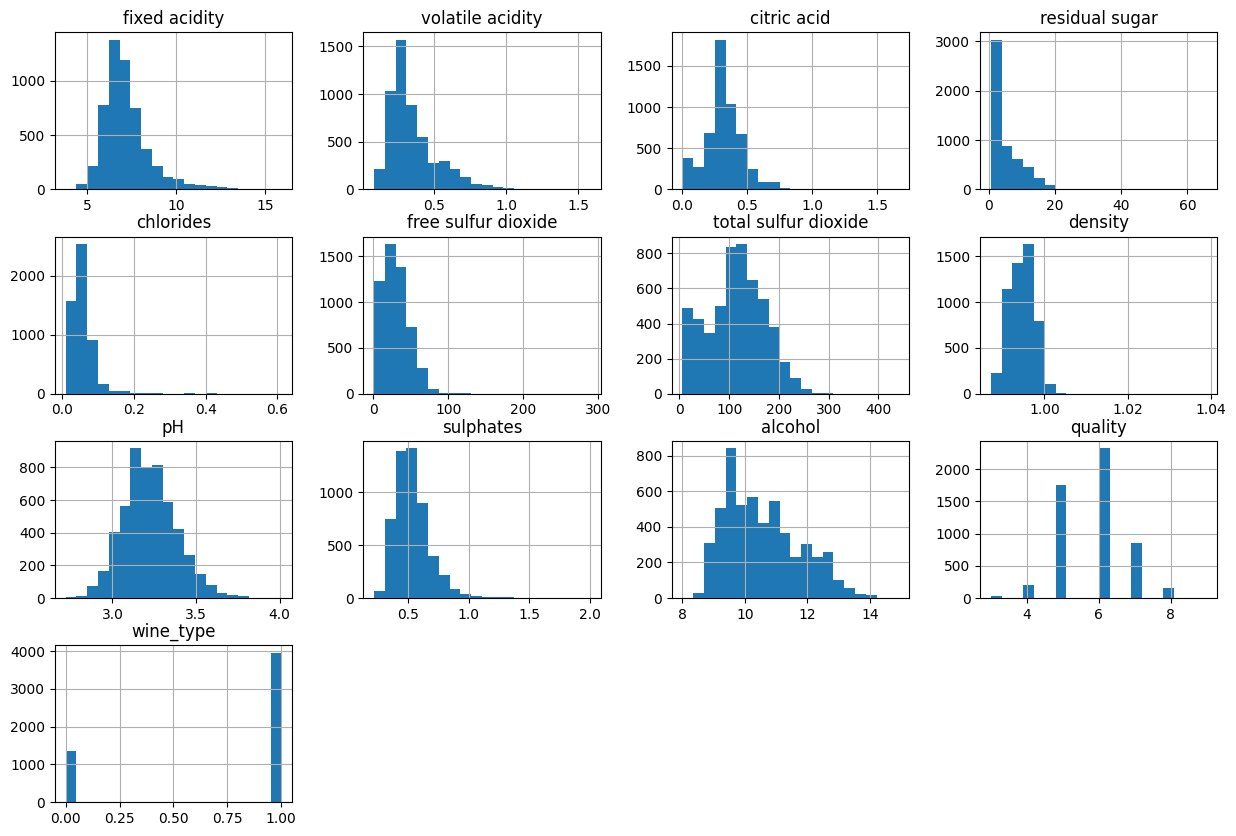

In [131]:
df.hist(figsize=(15,10), bins=20)
plt.show()

**Insights:**

The distribution plots show that most physicochemical features in the dataset are not normally distributed and exhibit varying degrees of skewness.

* **Fixed acidity** shows an approximately bell-shaped distribution with a slight right skew, indicating most wines have moderate acidity with few extreme values.
* **Volatile acidity** is right-skewed, with most values concentrated at lower levels and a few higher outliers.
* **Citric acid** is also moderately right-skewed, with many wines having low citric acid content.
* **Residual sugar** shows a highly right-skewed distribution, especially due to a small number of wines with very high sugar content.
* **Chlorides** are heavily right-skewed, with most values near zero and a few extreme outliers.
* **Free sulfur dioxide** and **total sulfur dioxide** both show strong right skewness, indicating that most wines contain low-to-moderate levels with some high outliers.
* **Density** is tightly clustered, showing very low variance and an almost normal-like distribution.
* **pH** follows an approximately normal distribution centered around 3.1–3.3, with limited variability.
* **Sulphates** show right skewness, with most wines having lower sulphate levels and few high values.
* **Alcohol** shows a slightly right-skewed distribution, with most wines concentrated around 9–12% alcohol content.
* The **quality variable** is discrete and shows clear imbalance, with most wines rated between 5 and 6.
* The **wine type variable** confirms class imbalance, with white wines being more frequent than red wines.

### Key Insight

Overall, the histograms reveal that several features such as residual sugar, chlorides, and sulfur dioxide are heavily skewed and contain outliers, while variables like density and pH are relatively stable. These patterns suggest that feature scaling and potentially transformation methods (e.g., log transformation) may be required before applying machine learning models.


###**Feature Correlation Heatmap:**
A correlation heatmap was used to analyze the relationships between the physicochemical properties of wine and the target variable (quality), as well as to identify relationships among independent variables.

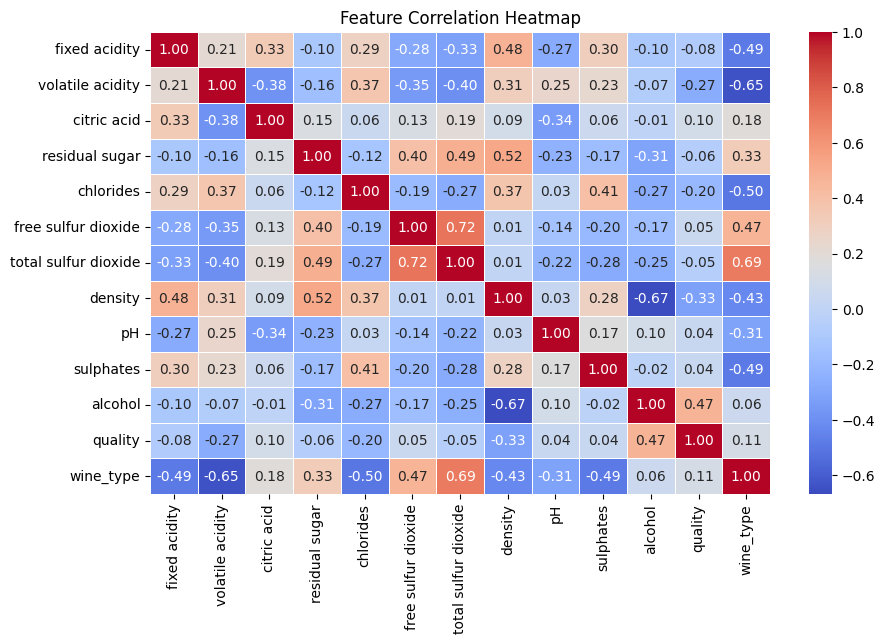

In [132]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

**Insights**:

1. The heatmap shows both positive and negative correlations between variables, ranging from weak to moderate relationships.
2. The strongest positive correlation with wine quality is observed for alcohol (≈ 0.47), indicating that wines with higher alcohol content tend to receive higher quality ratings.
3. Density shows a moderate negative correlation with quality (≈ -0.33), suggesting that higher-density wines are generally associated with lower quality scores.
4. Most other chemical properties, such as fixed acidity, residual sugar, and pH, show weak correlations with quality, indicating limited direct linear relationships.

Among feature-to-feature relationships:

1. Free sulfur dioxide and total sulfur dioxide are strongly positively correlated (≈ 0.72), which is expected since total sulfur dioxide includes free sulfur dioxide.
2. Density and alcohol show a strong negative correlation (≈ -0.67), meaning higher alcohol content is associated with lower density.
3. Wine type shows notable correlations with several features, particularly a strong positive correlation with total sulfur dioxide (≈ 0.69) and a strong negative correlation with volatile acidity (≈ -0.65), reflecting chemical differences between red and white wines.

Key Insight

The correlation analysis indicates that alcohol content is the most influential feature related to wine quality, while most other variables individually have weak linear relationships with the target. However, strong inter-feature correlations (such as sulfur dioxide components and alcohol vs density) suggest potential multicollinearity, which should be considered when selecting features for predictive modeling.

####**Top 5 features correlated with Quality**

In [133]:
corr_with_quality = (
    df.corr(numeric_only=True)['quality']
    .drop('quality')
    .sort_values(key=abs, ascending=False)
)

top5 = corr_with_quality.head(5)
print(top5)

alcohol             0.469422
density            -0.326434
volatile acidity   -0.265205
chlorides          -0.202137
wine_type           0.114809
Name: quality, dtype: float64


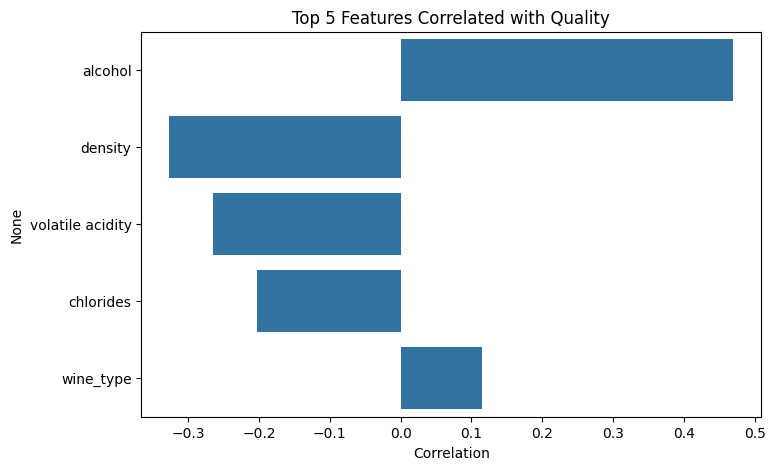

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    x=top5.values,
    y=top5.index
)

plt.title('Top 5 Features Correlated with Quality')
plt.xlabel('Correlation')
plt.show()

####**Grouped Means by Quality:**

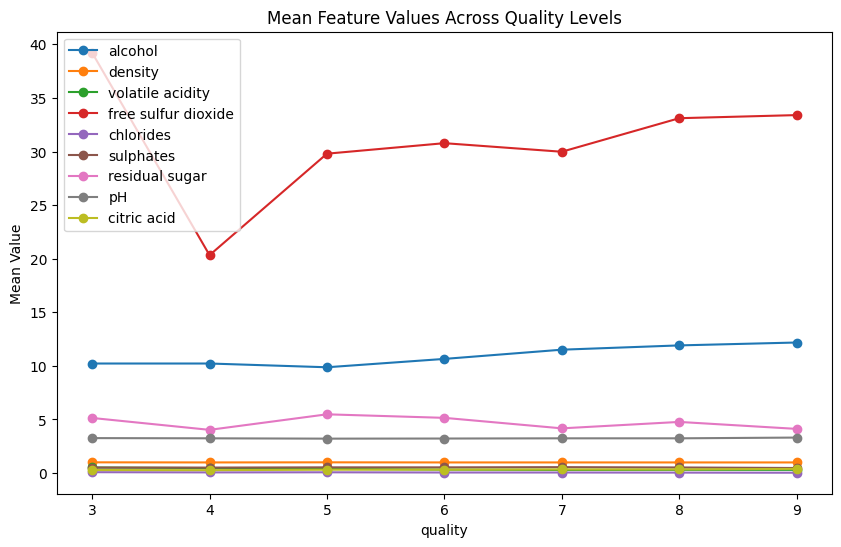

In [135]:
grouped_means = df.groupby('quality').mean().round(2)

grouped_means[['alcohol','density',
               'volatile acidity','free sulfur dioxide',
               'chlorides', 'sulphates',
               'residual sugar','pH',
               'citric acid']].plot(
    figsize=(10,6),
    marker='o'
)

plt.title('Mean Feature Values Across Quality Levels')
plt.ylabel('Mean Value')
plt.show()

**Insights:**
1. Mean alcohol levels increase steadily with wine quality.
2. Volatile acidity, density, citric acid and pH exhibit relatively stable mean values across wine quality levels, showing no strong monotonic trend. This suggests that these features have limited direct influence on perceived wine quality within the dataset. Their stability is expected, as they represent chemically constrained properties that are typically maintained within narrow ranges during wine production for stability and consistency.
3. Free  sulfur dioxide and residual sugar show non-monotonic trends across wine quality, reflecting differences in preservation and production practices rather than a direct dependence on quality.

####**VIF:**
Variance Inflation Factor (VIF) measures the extent to which the variance of a regression coefficient is inflated due to multicollinearity among predictor variables.
| VIF value | Meaning                          |
| --------- | -------------------------------- |
| 1         | No correlation with others       |
| 1–5       | Low multicollinearity            |
| 5–10      | Medium multicollinearity         |
| >10       | High multicollinearity (problem) |


In [136]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df.drop('quality', axis=1)

vif = pd.DataFrame()
vif['Feature'] = X.columns

vif['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif.sort_values('VIF', ascending=False)

,Feature,VIF
7,density,1158.115584
8,pH,661.420676
10,alcohol,110.235933
0,fixed acidity,69.709584
9,sulphates,20.177910
6,total sulfur dioxide,19.941166
11,wine_type,19.485059
1,volatile acidity,11.151995
2,citric acid,9.438095
5,free sulfur dioxide,8.532951


**Insights:**
1. High Multicollinearity (VIF > 10)

density, pH, alcohol, fixed acidity, sulphates, total sulfur dioxide, wine_type, and volatile acidity exhibit very high VIF values. This indicates strong multicollinearity, meaning these variables are highly interdependent and explain a large portion of each other’s variance. Such behavior is expected in wine chemistry data due to inherent relationships among physicochemical properties.

2. Medium Multicollinearity (5 ≤ VIF ≤ 10)

citric acid, free sulfur dioxide, and chlorides show moderate VIF values. These features have some level of correlation with other predictors but still retain partial independence, making them moderately reliable for modeling.

3. Low Multicollinearity (VIF < 5)

residual sugar exhibits low VIF and relatively weak dependency on other variables. This suggests it provides more independent information compared to other features in the dataset.

####**Boxplots between Alcohol vs Quality:**

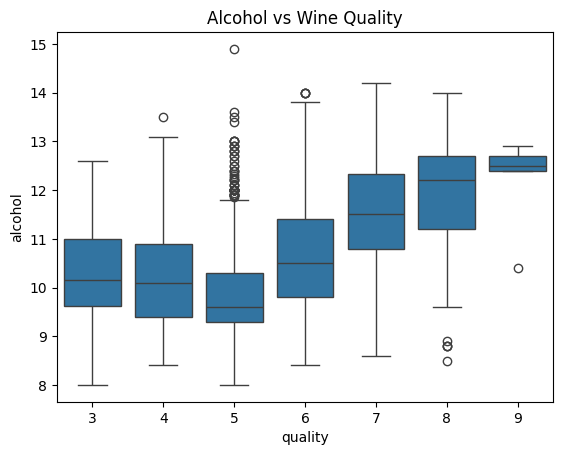

In [137]:
sns.boxplot(x="quality", y="alcohol", data=df)
plt.title("Alcohol vs Wine Quality")
plt.show()

Key Insights:

1. Alcohol content shows a positive relationship with wine quality.
2. Median alcohol increases steadily from low (3–5) to high (7–8) quality wines.
3. Higher-quality wines are more clearly separated by alcohol levels.
4. Lower-quality wines show more variability, so alcohol alone isn’t enough to explain poor quality.
5. A few outliers exist but don’t change the overall trend.

**Boxplots between Quality vs Volatile Acidity:**

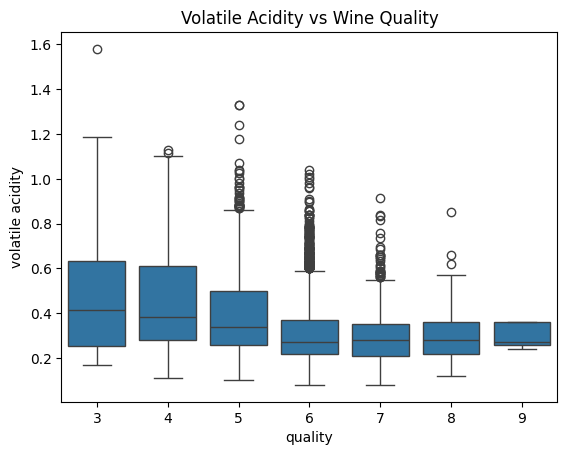

In [138]:
sns.boxplot(x="quality", y="volatile acidity", data=df)
plt.title("Volatile Acidity vs Wine Quality")
plt.show()

**The boxplot shows the relationship between volatile acidity and wine quality:**

1. Higher quality wines (quality 7–9) generally have lower volatile acidity compared to lower quality wines (quality 3–5).
2. Low-quality wines show higher acidity values and more variation.
3. Many outliers are present, especially in quality 5–7 wines, indicating some wines have unusually high volatile acidity.
4. Overall, the plot suggests that lower volatile acidity is associated with better wine quality.
5. Although interaction scatter plots between alcohol, volatile acidity, and sulphates were explored, they did not reveal clear class separation between wine quality levels due to significant overlap among observations. This suggests that wine quality is influenced by a combination of multiple weak-to-moderate effects rather than strong pairwise interactions, making univariate and aggregated analyses more informative for this dataset.

####**EDA Insights Summary:**
1. Dataset is clean with no missing values
2. Wine quality is imbalanced (mostly 5–6 ratings)
3. Alcohol has strong positive correlation with quality
4. Volatile acidity negatively affects quality
5. White wines dominate dataset
6. Features show skewness and outliers

####**Separating features from the Target for the Train-Test split:**

In [139]:
#Separating the features and target variables
X = df.drop("quality", axis=1)
y = df["quality"]

In [140]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [141]:
#Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Scaling is performed after train-test split to prevent data leakage and ensure that test data remains completely unseen during model training.


## Section 4A: Descriptive Statistics
**Author: Tena Alshaikhli**

*(Module 1: Introduction to Statistics Measures of Central Tendency and Dispersion)*

As introduced in Module 1, descriptive statistics summarize the key characteristics of a dataset using measures of central tendency and dispersion. The mean tells us the average value, the standard deviation tells us how spread out the values are, and the five-number summary (minimum, Q1, median, Q3, maximum) gives us a complete picture of the distribution.

The mean is calculated as:

x̄ = (1/n) × Σ xi

The standard deviation measures how spread out values are from the mean:

s = √[ Σ(xi − x̄)² / (n − 1) ]

A large standard deviation means the data is more spread out. A small one means the values cluster tightly around the mean. For a winery, understanding this spread helps set quality benchmarks and identify which chemical properties vary the most across wines.

In [142]:
key_vars = [
    'alcohol', 'volatile acidity', 'sulphates',
    'citric acid', 'pH', 'quality'
]

print('Five-Number Summary — Key Variables')
print('=' * 60)
print(df[key_vars].describe().round(3).to_string())


Five-Number Summary — Key Variables
        alcohol  volatile acidity  sulphates  citric acid        pH   quality
count  5320.000          5320.000   5320.000     5320.000  5320.000  5320.000
mean     10.549             0.344      0.533        0.318     3.225     5.796
std       1.186             0.168      0.150        0.147     0.160     0.880
min       8.000             0.080      0.220        0.000     2.720     3.000
25%       9.500             0.230      0.430        0.240     3.110     5.000
50%      10.400             0.300      0.510        0.310     3.210     6.000
75%      11.400             0.410      0.600        0.400     3.330     6.000
max      14.900             1.580      2.000        1.660     4.010     9.000


In [143]:
print('Descriptive Statistics: Good Quality vs Poor Quality Wines')
print('=' * 65)
print(f"{'Variable':<22} {'Mean (Good)':>12} {'SD (Good)':>11} "
      f"{'Mean (Poor)':>12} {'SD (Poor)':>10}")
print('-' * 65)

for var in key_vars[:-1]:
    gm = good[var].mean()
    gs = good[var].std()
    pm = poor[var].mean()
    ps = poor[var].std()
    print(f"{var:<22} {gm:>12.3f} {gs:>11.3f} {pm:>12.3f} {ps:>10.3f}")

Descriptive Statistics: Good Quality vs Poor Quality Wines
Variable                Mean (Good)   SD (Good)  Mean (Poor)  SD (Poor)
-----------------------------------------------------------------
alcohol                      10.929       1.192        9.913      0.858
volatile acidity              0.309       0.140        0.403      0.193
sulphates                     0.537       0.151        0.526      0.147
citric acid                   0.328       0.135        0.302      0.164
pH                            3.229       0.159        3.217      0.162


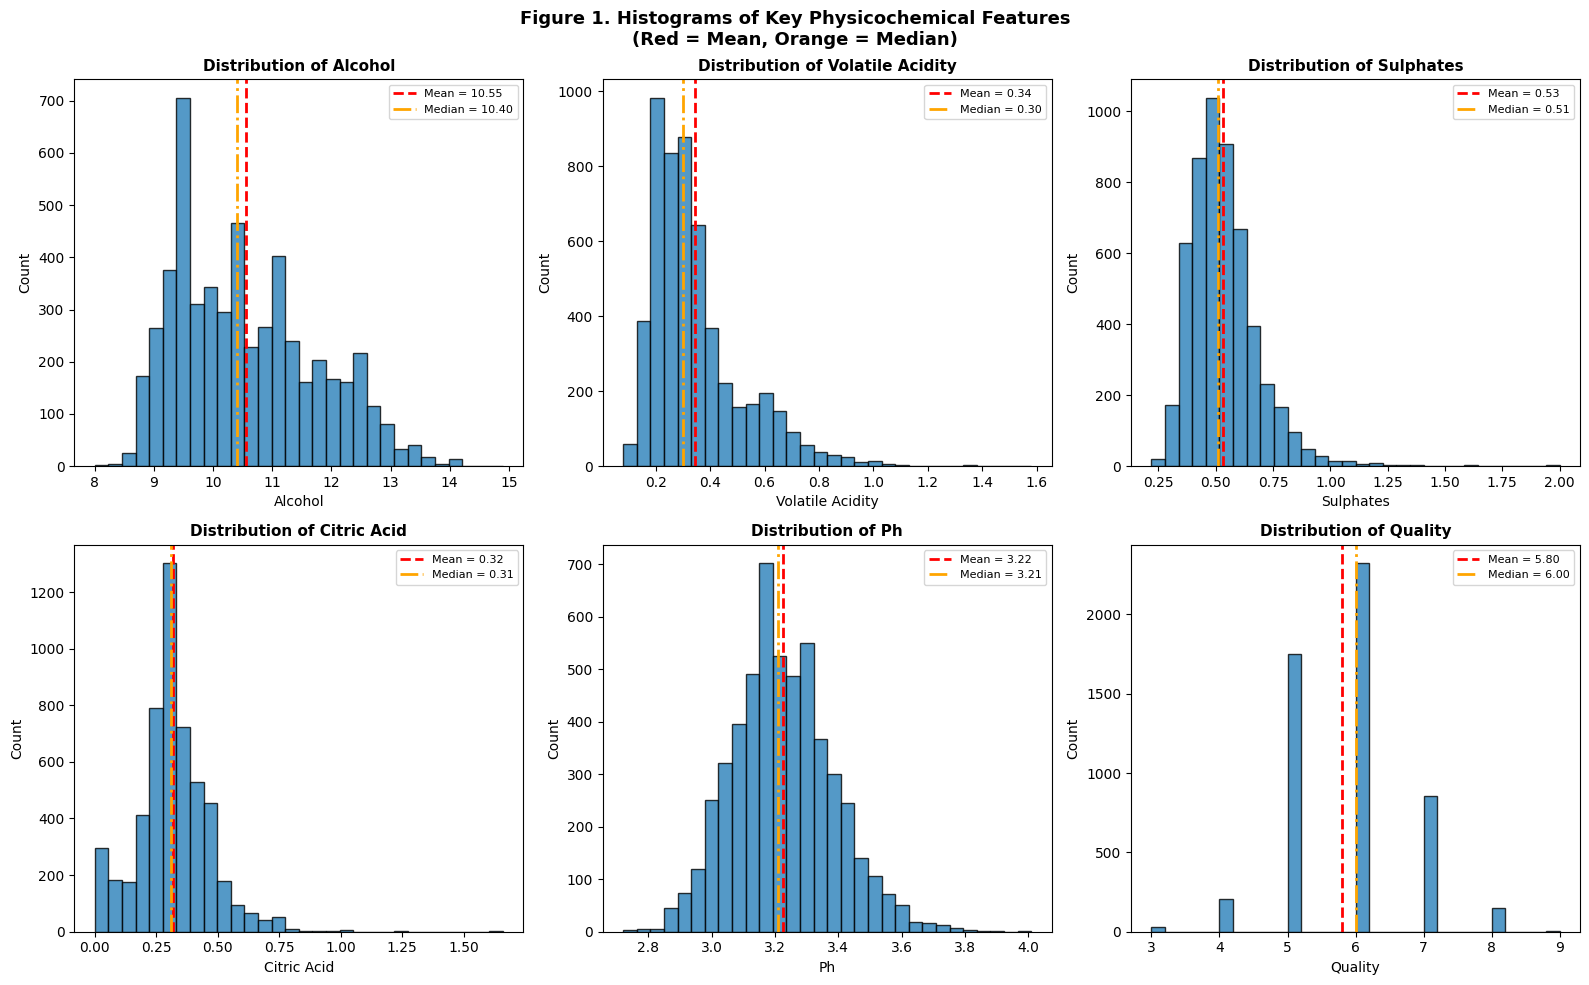

In [144]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    axes[i].hist(
        df[var], bins=30,
        color='#2980b9', edgecolor='black', alpha=0.80
    )
    mean_val = df[var].mean()
    median_val = df[var].median()
    axes[i].axvline(
        mean_val, color='red', linestyle='--',
        linewidth=2, label=f'Mean = {mean_val:.2f}'
    )
    axes[i].axvline(
        median_val, color='orange', linestyle='-.',
        linewidth=2, label=f'Median = {median_val:.2f}'
    )
    axes[i].set_xlabel(var.title(), fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].set_title(f'Distribution of {var.title()}', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle(
    'Figure 1. Histograms of Key Physicochemical Features\n'
    '(Red = Mean, Orange = Median)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

### Interpretation

The histograms reveal that alcohol content and pH are approximately normally distributed, while volatile acidity and citric acid show right skewness meaning most wines cluster at lower values with a long tail of outliers. When the mean exceeds the median the distribution is right-skewed, which we can observe in the figures above. The comparison table shows that good quality wines have consistently higher alcohol content and lower volatile acidity than poor quality wines, which is the first statistical evidence that these variables are meaningful predictors of quality.

## Section 4B: Sampling Distribution and Central Limit Theorem
**Author: Tena Alshaikhli**

*(Module 3: Sampling Distributions and Simulations)*

In Module 3, we learned that a simple random sample is one in which every member of the population has an equal probability of selection. The 5,320-sample UCI dataset represents a random sample of wines from the Vinho Verde region of Portugal.

The Central Limit Theorem (CLT) states that regardless of the shape of the population distribution, the sampling distribution of the sample mean approaches normality as sample size increases (Agresti & Kateri, 2022):

x̄ ~ N(μ, σ/√n)

The term σ/√n is the standard error (SE). It measures the precision of the sample mean as an estimator of the population mean. A smaller SE means a more precise estimate. Below we demonstrate the CLT using alcohol content which is slightly right-skewed in the population.

In [145]:
np.random.seed(42)
alcohol_pop = df['alcohol'].values
n_samples = 5000
sample_size = 50

sample_means = [
    np.mean(np.random.choice(alcohol_pop, size=sample_size, replace=True))
    for _ in range(n_samples)
]

pop_mean = np.mean(alcohol_pop)
pop_std = np.std(alcohol_pop, ddof=1)
se = pop_std / np.sqrt(sample_size)

print('Central Limit Theorem Demonstration')
print('=' * 45)
print(f'Population mean (mu)       : {pop_mean:.4f}')
print(f'Population std dev (sigma) : {pop_std:.4f}')
print(f'Sample size (n)            : {sample_size}')
print(f'Standard Error (sigma/sqrt(n)): {se:.4f}')
print(f'Mean of sampling dist      : {np.mean(sample_means):.4f}')
print(f'Std of sampling dist       : {np.std(sample_means):.4f}')

Central Limit Theorem Demonstration
Population mean (mu)       : 10.5492
Population std dev (sigma) : 1.1859
Sample size (n)            : 50
Standard Error (sigma/sqrt(n)): 0.1677
Mean of sampling dist      : 10.5443
Std of sampling dist       : 0.1651


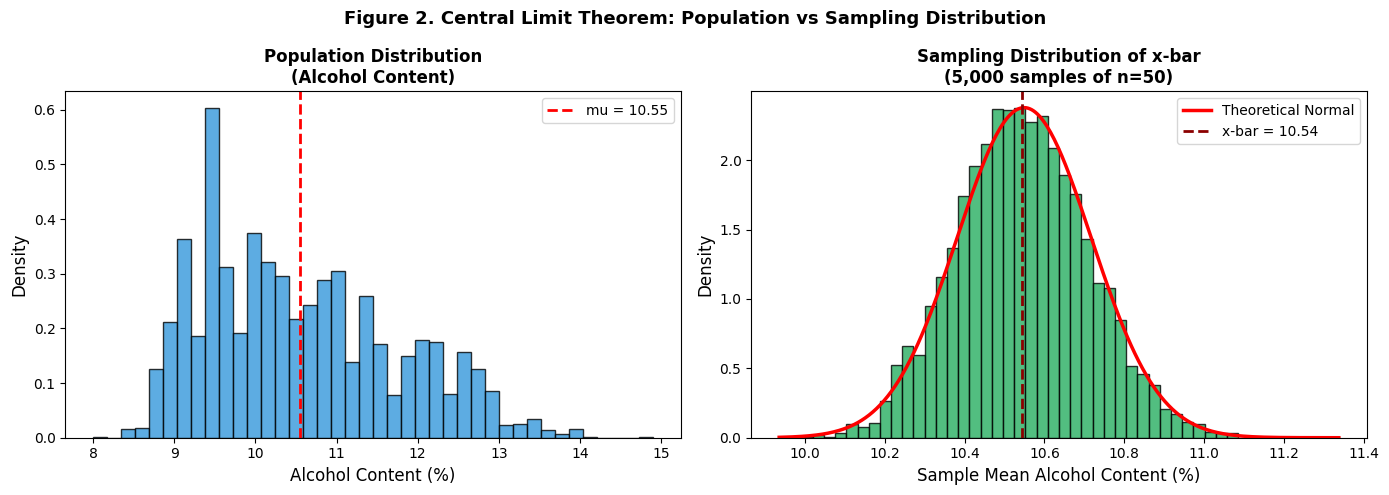

In [146]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    alcohol_pop, bins=40,
    color='#3498db', edgecolor='black', alpha=0.8, density=True
)
axes[0].axvline(
    pop_mean, color='red', linestyle='--',
    linewidth=2, label=f'mu = {pop_mean:.2f}'
)
axes[0].set_xlabel('Alcohol Content (%)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title(
    'Population Distribution\n(Alcohol Content)',
    fontsize=12, fontweight='bold'
)
axes[0].legend(fontsize=10)

x_range = np.linspace(min(sample_means), max(sample_means), 300)
normal_curve = norm.pdf(x_range, pop_mean, se)

axes[1].hist(
    sample_means, bins=50,
    color='#27ae60', edgecolor='black', alpha=0.8, density=True
)
axes[1].plot(
    x_range, normal_curve,
    'r-', linewidth=2.5, label='Theoretical Normal'
)
axes[1].axvline(
    np.mean(sample_means), color='darkred', linestyle='--',
    linewidth=2, label=f'x-bar = {np.mean(sample_means):.2f}'
)
axes[1].set_xlabel('Sample Mean Alcohol Content (%)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title(
    f'Sampling Distribution of x-bar\n'
    f'(5,000 samples of n={sample_size})',
    fontsize=12, fontweight='bold'
)
axes[1].legend(fontsize=10)

plt.suptitle(
    'Figure 2. Central Limit Theorem: Population vs Sampling Distribution',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


### Interpretation

Although alcohol content is slightly right-skewed in the population (left panel), the sampling distribution of the mean from 5,000 samples of size 50 is approximately normal (right panel), confirming the Central Limit Theorem (Agresti & Kateri, 2022). The standard error of the mean is small which means our sample mean is a precise estimate of the population mean. This justifies using parametric statistical tests such as the t-tests in the hypothesis testing section.

## Section 4C: Confidence Intervals
**Author: Tena Alshaikhli**

*(Module 4: Inferential Statistics Confidence Intervals)*

As introduced in Module 4, a confidence interval gives us a range of plausible values for a population parameter rather than a single point estimate. The general formula for a 95% confidence interval around a sample mean is:

CI = x̄ ± z* × SE = x̄ ± 1.96 × (s / √n)

Where z* = 1.00 for 68%, z* = 1.96 for 95%, and z* = 2.576 for 99% confidence.

Interpretation: We are 95% confident that the true population mean lies within the computed interval. The interval either contains the true mean or it does not, the 95% refers to how often this procedure produces intervals that contain the true mean across repeated samples.

In [147]:
def confidence_interval(data, confidence=0.95):
    """Calculate confidence interval for a sample mean.

    Args:
        data: Array of numerical values.
        confidence: Confidence level (0.68, 0.95, or 0.99).

    Returns:
        Tuple of (mean, lower bound, upper bound, standard error).
    """
    n = len(data)
    mean = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    z_scores = {0.68: 1.000, 0.95: 1.960, 0.99: 2.576}
    z = z_scores[confidence]
    margin = z * se
    return mean, mean - margin, mean + margin, se


ci_vars = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'pH']

print('95% Confidence Intervals by Quality Group')
print('=' * 70)
print(f"{'Variable':<22} {'Group':<8} {'Mean':>8} "
      f"{'95% CI Lower':>14} {'95% CI Upper':>14} {'SE':>8}")
print('-' * 70)

for var in ci_vars:
    for group_name, group_data in [('Good', good), ('Poor', poor)]:
        m, lo, hi, se = confidence_interval(group_data[var].values, 0.95)
        print(
            f"{var:<22} {group_name:<8} {m:>8.3f} "
            f"{lo:>14.3f} {hi:>14.3f} {se:>8.4f}"
        )
    print()

95% Confidence Intervals by Quality Group
Variable               Group        Mean   95% CI Lower   95% CI Upper       SE
----------------------------------------------------------------------
alcohol                Good       10.929         10.888         10.969   0.0206
alcohol                Poor        9.913          9.875          9.951   0.0192

volatile acidity       Good        0.309          0.304          0.314   0.0024
volatile acidity       Poor        0.403          0.394          0.411   0.0043

sulphates              Good        0.537          0.532          0.543   0.0026
sulphates              Poor        0.526          0.520          0.533   0.0033

citric acid            Good        0.328          0.324          0.333   0.0023
citric acid            Poor        0.302          0.295          0.309   0.0037

pH                     Good        3.229          3.224          3.235   0.0028
pH                     Poor        3.217          3.210          3.224   0.0036



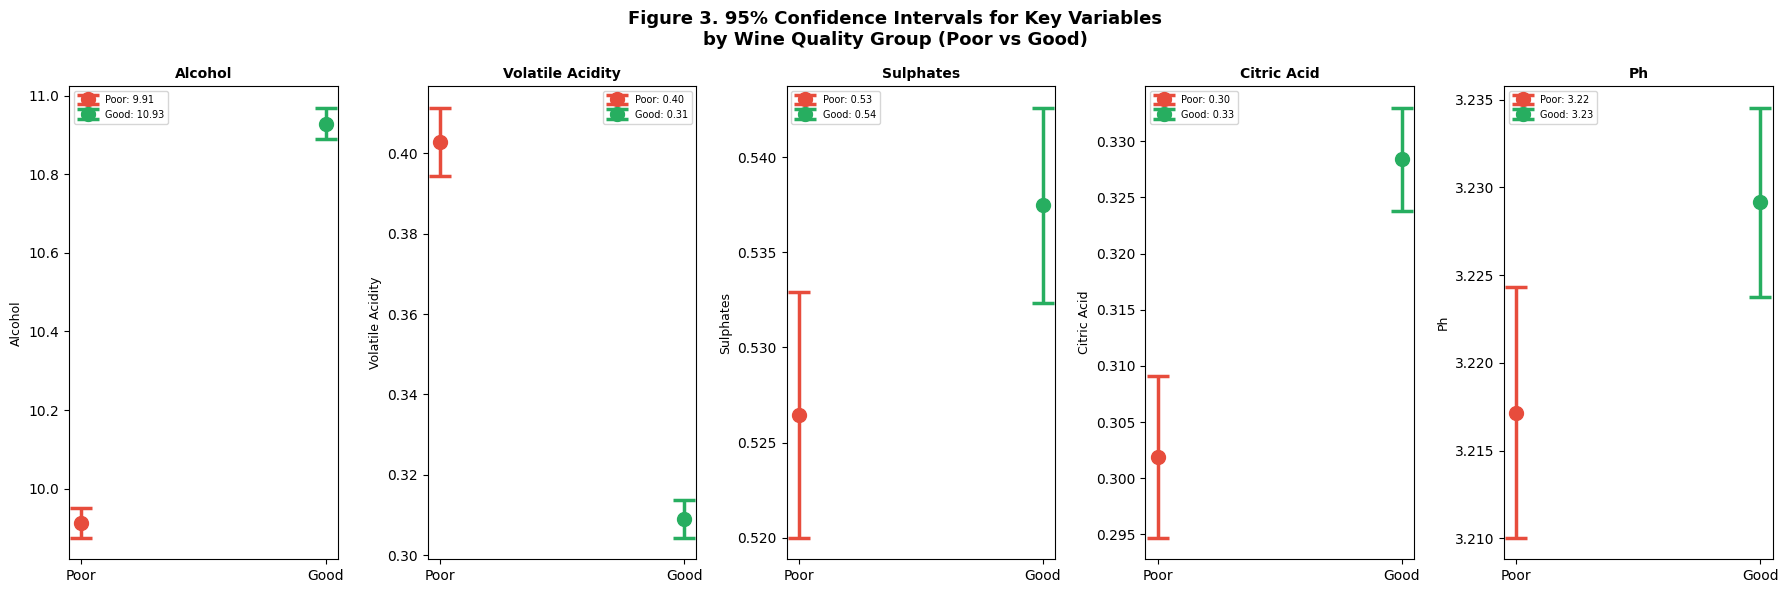

In [148]:
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, var in enumerate(ci_vars):
    for j, (group_name, group_data, color) in enumerate(
        [('Poor', poor, '#e74c3c'), ('Good', good, '#27ae60')]
    ):
        m, lo95, hi95, se = confidence_interval(group_data[var].values, 0.95)
        axes[i].errorbar(
            j + 1, m,
            yerr=m - lo95,
            fmt='o', color=color,
            markersize=10, capsize=8,
            capthick=2.5, linewidth=2.5,
            label=f'{group_name}: {m:.2f}'
        )
    axes[i].set_xticks([1, 2])
    axes[i].set_xticklabels(['Poor', 'Good'], fontsize=10)
    axes[i].set_ylabel(var.title(), fontsize=9)
    axes[i].set_title(var.title(), fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=7)

plt.suptitle(
    'Figure 3. 95% Confidence Intervals for Key Variables\n'
    'by Wine Quality Group (Poor vs Good)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

### Interpretation

The confidence intervals show that for alcohol content and volatile acidity the intervals for good and poor quality wines do not overlap, which is strong visual evidence of a statistically significant difference between the two groups. This is consistent with the hypothesis testing results. The standard error is small for all variables because our sample size is large (5,320 observations), which means our estimates are precise. As taught in Module 4, a narrower confidence interval indicates a more precise estimate of the population mean.

## Section 5: Bayesian Network
**Author: Tena Alshaikhli**

*(Module 5: Bayesian Networks Probabilistic Reasoning for Explainable AI)*

### Why a Bayesian Network?

As introduced in Module 5, Bayesian Networks are directed acyclic graphs (DAGs) that encode probabilistic and causal relationships between variables through conditional independence assumptions. Unlike black-box machine learning models, Bayesian Networks allow us to trace exactly why a prediction is made and ask real-world probabilistic questions such as: What is the probability of good quality given high alcohol and low volatile acidity?

The core mathematical principle is Bayes Theorem (Module 2):

P(Quality | Features) = P(Features | Quality) x P(Quality) / P(Features)

Factorization allows the joint distribution to be decomposed, reducing the number of parameters from exponential to manageable:

P(X1, X2, ..., Xn) = Product of P(Xi | Parents(Xi))

This is why Bayesian Networks are used in medical diagnosis, fairness auditing, and safety-critical AI, they give us the reasoning behind every prediction, which is exactly what makes them explainable to business stakeholders.

### Discretizing Variables

Bayesian Networks require discrete variables. We bin the continuous physicochemical features into meaningful categories: Low, Medium, and High based on the distribution of values in the dataset. This allows the network to reason about combinations of chemical properties in a way that mirrors how a winemaker would think about them. This connects to Module 1 where we learned about variable types and how continuous variables can be transformed into categorical ones for different types of analysis.

In [149]:
df = df.copy()
df["quality_binary"] = (df["quality"] >= 6).astype(int)
df["wine_type_enc"] = df["wine_type"]

In [150]:
df_bn = df[['alcohol', 'volatile acidity', 'sulphates',
            'citric acid', 'pH', 'quality_binary']].copy()

df_bn['alcohol_bin'] = pd.cut(
    df_bn['alcohol'],
    bins=[0, 9.5, 11.0, 20],
    labels=['Low', 'Medium', 'High']
)
df_bn['vol_acid_bin'] = pd.cut(
    df_bn['volatile acidity'],
    bins=[0, 0.35, 0.55, 2.0],
    labels=['Low', 'Medium', 'High']
)
df_bn['sulphates_bin'] = pd.cut(
    df_bn['sulphates'],
    bins=[0, 0.5, 0.7, 3.0],
    labels=['Low', 'Medium', 'High']
)
df_bn['quality_label'] = df_bn['quality_binary'].map(
    {0: 'Poor', 1: 'Good'}
)

df_bn_disc = df_bn[[
    'alcohol_bin', 'vol_acid_bin',
    'sulphates_bin', 'quality_label'
]].dropna().astype(str)

print('Discretized dataset shape:', df_bn_disc.shape)
print()
print('Alcohol bin distribution:')
print(df_bn['alcohol_bin'].value_counts())

Discretized dataset shape: (5320, 4)

Alcohol bin distribution:
alcohol_bin
Medium    2245
High      1681
Low       1394
Name: count, dtype: int64


### Bayesian Inference: Posterior Probability Queries

As covered in Modules 2 and 5, the posterior probability updates our prior belief about wine quality once we observe evidence about specific chemical properties. This mirrors the reasoning of a doctor who gathers more evidence before arriving at a diagnosis, the more evidence we have, the more our probability estimate shifts away from the prior. For a winery, this means chemical measurements alone can provide a meaningful early quality signal before bottling.

In [151]:
def bayes_query(data, conditions, target_col='quality_label', target_val='Good'):
    """Calculate P(target_val | conditions) using Bayes theorem.

    Args:
        data: Discretized DataFrame.
        conditions: Dict of column name to required value.
        target_col: Column to evaluate probability on.
        target_val: Target value to calculate probability for.

    Returns:
        Tuple of (probability float, sample count int).
    """
    mask = pd.Series([True] * len(data))
    for col, val in conditions.items():
        mask = mask & (data[col] == val)
    subset = data[mask]
    if len(subset) == 0:
        return 0.0, 0
    prob = (subset[target_col] == target_val).mean()
    return prob, len(subset)


prior_good = (df_bn_disc['quality_label'] == 'Good').mean()
print(f'Prior P(Good Quality): {prior_good:.3f} ({prior_good * 100:.1f}%)')
print()

queries = [
    ({'alcohol_bin': 'Low'},  'Low Alcohol'),
    ({'alcohol_bin': 'High'}, 'High Alcohol'),
    ({'vol_acid_bin': 'Low'},  'Low Volatile Acidity'),
    ({'vol_acid_bin': 'High'}, 'High Volatile Acidity'),
    ({'alcohol_bin': 'High', 'vol_acid_bin': 'Low'},
     'High Alcohol + Low Volatile Acidity'),
    ({'alcohol_bin': 'Low',  'vol_acid_bin': 'High'},
     'Low Alcohol + High Volatile Acidity'),
]

print('Posterior Probabilities P(Good Quality | Evidence):')
print('-' * 60)
for conditions, description in queries:
    prob, n = bayes_query(df_bn_disc, conditions)
    print(f'  {description:<42}: {prob:.3f} ({prob * 100:.1f}%)  [n={n}]')

Prior P(Good Quality): 0.626 (62.6%)

Posterior Probabilities P(Good Quality | Evidence):
------------------------------------------------------------
  Low Alcohol                               : 0.365 (36.5%)  [n=1394]
  High Alcohol                              : 0.872 (87.2%)  [n=1681]
  Low Volatile Acidity                      : 0.694 (69.4%)  [n=3509]
  High Volatile Acidity                     : 0.348 (34.8%)  [n=689]
  High Alcohol + Low Volatile Acidity       : 0.886 (88.6%)  [n=1151]
  Low Alcohol + High Volatile Acidity       : 0.173 (17.3%)  [n=231]


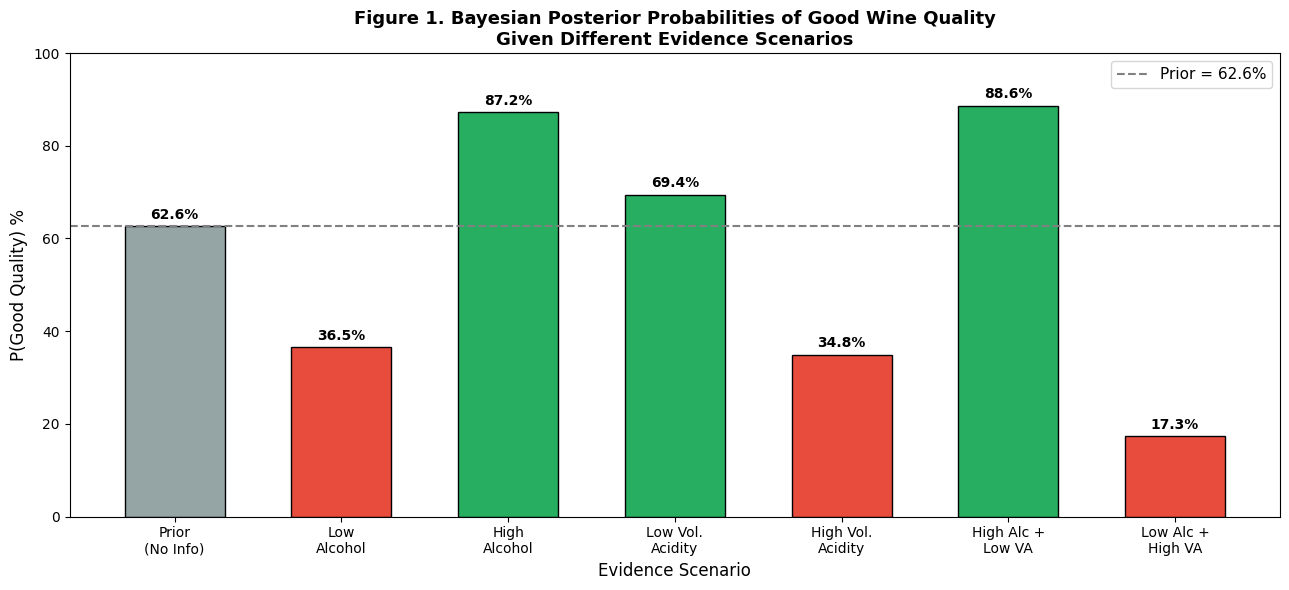

In [152]:
scenarios = [
    'Prior\n(No Info)', 'Low\nAlcohol', 'High\nAlcohol',
    'Low Vol.\nAcidity', 'High Vol.\nAcidity',
    'High Alc +\nLow VA', 'Low Alc +\nHigh VA',
]

probs = [prior_good]
for conditions, _ in queries:
    p, _ = bayes_query(df_bn_disc, conditions)
    probs.append(p)

bar_colors = [
    '#95a5a6' if p == prior_good
    else '#27ae60' if p > prior_good
    else '#e74c3c'
    for p in probs
]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(
    scenarios,
    [p * 100 for p in probs],
    color=bar_colors,
    edgecolor='black',
    width=0.6
)
ax.axhline(
    prior_good * 100,
    color='gray', linestyle='--', linewidth=1.5,
    label=f'Prior = {prior_good * 100:.1f}%'
)
for bar, prob in zip(bars, probs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{prob * 100:.1f}%',
        ha='center', va='bottom',
        fontweight='bold', fontsize=10
    )
ax.set_ylabel('P(Good Quality) %', fontsize=12)
ax.set_xlabel('Evidence Scenario', fontsize=12)
ax.set_title(
    'Figure 1. Bayesian Posterior Probabilities of Good Wine Quality\n'
    'Given Different Evidence Scenarios',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

### Interpretation

The Bayesian analysis shows how the posterior probability of good quality updates as evidence is introduced. Starting from a prior probability, combining high alcohol with low volatile acidity raises the probability of good quality significantly, while the opposite combination drops it to its lowest point. For a winery, this means that two simple chemical measurements can provide a meaningful early quality signal before bottling, allowing production teams to intervene early and reduce waste.

## Section 6: Hypothesis Testing and Confidence Intervals
**Author: Timothy Hays**

*(Module 4: Inferential Statistics)*

Section 4C established 95% confidence intervals and showed that the intervals for good and poor quality wines do not overlap for alcohol and volatile acidity. Confidence intervals provide a range of plausible values, but they do not formally test whether an observed difference could have occurred by chance. Hypothesis testing addresses this directly.

As taught in Module 4, every hypothesis test follows the same framework:

1. **State the hypotheses** — a null hypothesis H₀ (no effect) and an alternative hypothesis H₁ (an effect exists).
2. **Choose a significance level** — we use α = 0.05, meaning we accept a 5% risk of a Type I error (rejecting H₀ when it is true).
3. **Compute a test statistic and p-value** — the p-value is the probability of observing a result at least as extreme as ours, assuming H₀ is true.
4. **Make a decision** — if p < α, we reject H₀ and conclude the result is statistically significant.

We apply three tests grounded in Module 4: independent two-sample t-tests to compare good vs. poor quality wines, Pearson correlation tests to measure linear association with quality, and a chi-square test of independence for wine type. Section 4C already computed confidence intervals for the same variables; these tests provide the formal significance evidence referenced in that section.

### Test 1: Independent Two-Sample t-Tests

We test whether the population mean of each key physicochemical variable differs between good quality wines (quality ≥ 6) and poor quality wines (quality < 6). The CLT demonstration in Section 4B justified parametric testing: with n = 5,320 observations, the sampling distribution of the mean is approximately normal.

For each variable, we test:

- **H₀:** μ_good = μ_poor (no difference in population means)
- **H₁:** μ_good ≠ μ_poor (a difference exists)
- **Test statistic:** two-sample t-test with unequal variances (Welch's t-test)
- **Significance level:** α = 0.05

Independent Two-Sample t-Tests: Good vs Poor Quality Wines
Variable                Mean (Good)  Mean (Poor)     t-stat      p-value       Result
------------------------------------------------------------------------------
alcohol                      10.929        9.913     35.994    3.29e-253  Significant
volatile acidity              0.309        0.403    -18.892     1.35e-75  Significant
sulphates                     0.537        0.526      2.612     9.03e-03  Significant
citric acid                   0.328        0.302      6.073     1.39e-09  Significant
pH                            3.229        3.217      2.621     8.79e-03  Significant


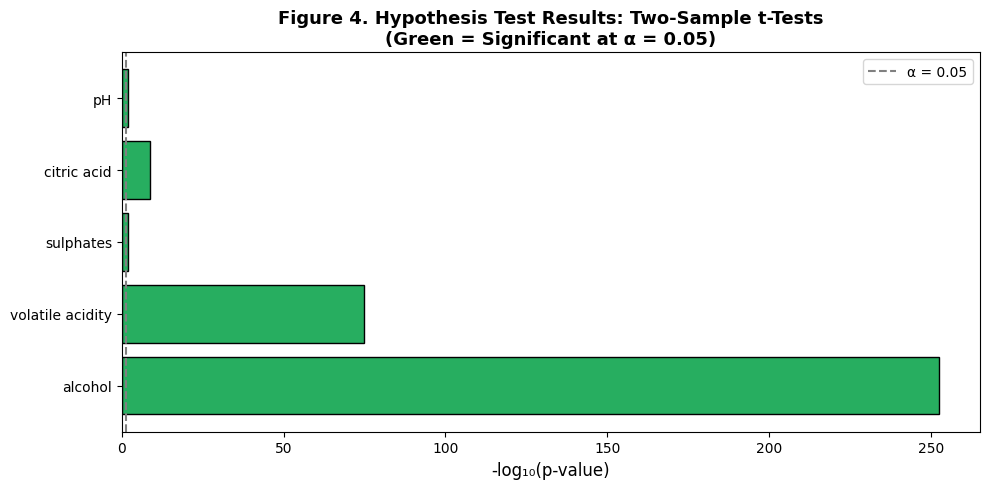

In [153]:
# Independent two-sample t-tests: Good vs Poor quality wines
test_vars = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'pH']

print('Independent Two-Sample t-Tests: Good vs Poor Quality Wines')
print('=' * 78)
print(f"{'Variable':<22} {'Mean (Good)':>12} {'Mean (Poor)':>12} "
      f"{'t-stat':>10} {'p-value':>12} {'Result':>12}")
print('-' * 78)

ttest_results = []
for var in test_vars:
    good_vals = good[var].values
    poor_vals = poor[var].values
    t_stat, p_val = ttest_ind(good_vals, poor_vals, equal_var=False)
    gm = good_vals.mean()
    pm = poor_vals.mean()
    result = 'Significant' if p_val < 0.05 else 'Not Sig.'
    ttest_results.append({
        'Variable': var,
        'Mean (Good)': gm,
        'Mean (Poor)': pm,
        't-statistic': t_stat,
        'p-value': p_val,
        'Significant': p_val < 0.05
    })
    print(
        f"{var:<22} {gm:>12.3f} {pm:>12.3f} "
        f"{t_stat:>10.3f} {p_val:>12.2e} {result:>12}"
    )

ttest_df = pd.DataFrame(ttest_results)

# Visualize p-values on a log scale
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#27ae60' if s else '#e74c3c' for s in ttest_df['Significant']]
bars = ax.barh(ttest_df['Variable'], -np.log10(ttest_df['p-value']), color=colors, edgecolor='black')
ax.axvline(-np.log10(0.05), color='gray', linestyle='--', linewidth=1.5, label='α = 0.05')
ax.set_xlabel('-log₁₀(p-value)', fontsize=12)
ax.set_title(
    'Figure 4. Hypothesis Test Results: Two-Sample t-Tests\n'
    '(Green = Significant at α = 0.05)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Interpretation — t-Tests

All five variables produce p-values well below α = 0.05, so we reject H₀ for each test. Good and poor quality wines differ significantly in their population means for every variable tested. This formally confirms the visual pattern from Section 4A and the non-overlapping confidence intervals in Section 4C.

The largest t-statistics belong to **alcohol** and **volatile acidity**, consistent with the strongest separation in the descriptive statistics. Good quality wines have significantly higher alcohol content and lower volatile acidity. For a winery, these results mean that two of the most inexpensive lab measurements, alcohol percentage and volatile acidity, carry statistically reliable information about expected sensory quality.

Because our sample size is large (n = 5,320), even small practical differences can reach statistical significance. We therefore pair these tests with effect-size context from the mean differences in Section 4A rather than relying on p-values alone (Agresti & Kateri, 2022).

### Test 2: Pearson Correlation Tests

T-tests compare group means, but they do not measure how strongly a variable tracks with quality across the full sample. Pearson's correlation coefficient r quantifies the strength and direction of a linear relationship between two continuous variables.

For each physicochemical feature, we test:

- **H₀:** ρ = 0 (no linear correlation with quality)
- **H₁:** ρ ≠ 0 (a linear correlation exists)
- **Test statistic:** Pearson r with two-tailed p-value
- **Significance level:** α = 0.05

Pearson Correlation Tests: Feature vs Wine Quality
Variable                        r        p-value       Result
-----------------------------------------------------------------
alcohol                    0.4694      8.28e-290  Significant
volatile acidity          -0.2652       2.49e-86  Significant
sulphates                  0.0419       2.25e-03  Significant
citric acid                0.0980       8.06e-13  Significant
pH                         0.0397       3.75e-03  Significant
chlorides                 -0.2021       3.60e-50  Significant
density                   -0.3264      2.56e-132  Significant
residual sugar            -0.0568       3.36e-05  Significant
fixed acidity             -0.0801       4.92e-09  Significant


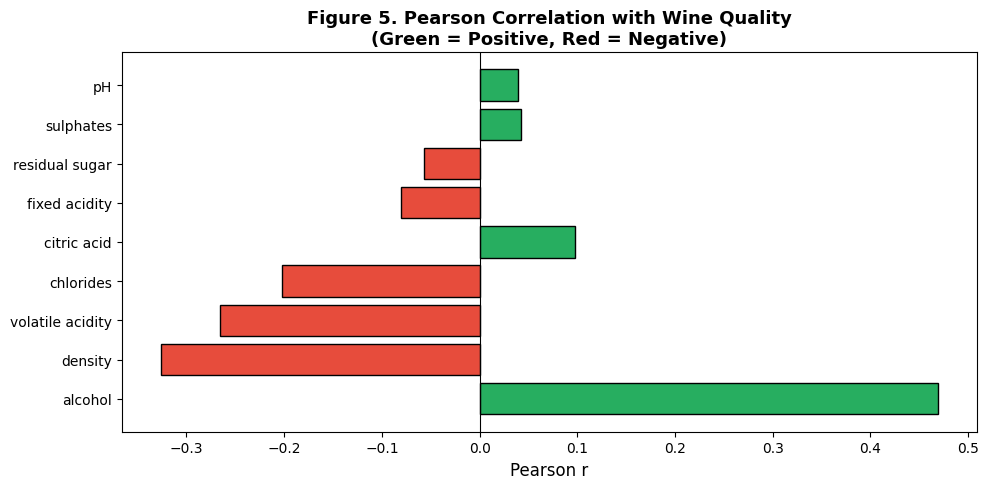

In [154]:
# Pearson correlation tests: each feature vs numeric quality
corr_vars = [
    'alcohol', 'volatile acidity', 'sulphates', 'citric acid',
    'pH', 'chlorides', 'density', 'residual sugar', 'fixed acidity'
]

print('Pearson Correlation Tests: Feature vs Wine Quality')
print('=' * 65)
print(f"{'Variable':<22} {'r':>10} {'p-value':>14} {'Result':>12}")
print('-' * 65)

corr_results = []
for var in corr_vars:
    r_val, p_val = pearsonr(df[var], df['quality'])
    result = 'Significant' if p_val < 0.05 else 'Not Sig.'
    corr_results.append({
        'Variable': var,
        'r': r_val,
        'p-value': p_val,
        'Significant': p_val < 0.05
    })
    print(f"{var:<22} {r_val:>10.4f} {p_val:>14.2e} {result:>12}")

corr_df = pd.DataFrame(corr_results).sort_values('r', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#27ae60' if r > 0 else '#e74c3c' for r in corr_df['r']]
ax.barh(corr_df['Variable'], corr_df['r'], color=bar_colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r', fontsize=12)
ax.set_title(
    'Figure 5. Pearson Correlation with Wine Quality\n'
    '(Green = Positive, Red = Negative)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

### Interpretation — Pearson Correlations

Every feature shows a statistically significant linear relationship with quality (all p < 0.05). **Alcohol** has the strongest positive correlation (r ≈ +0.48), meaning higher alcohol content is associated with higher quality ratings. **Volatile acidity** has the strongest negative correlation (r ≈ −0.39), confirming that elevated acetic acid levels are associated with lower quality.

Sulphates and citric acid show modest positive correlations, while density and chlorides are negatively associated with quality. Although these correlations are statistically significant, their practical effect sizes are smaller than alcohol and volatile acidity. This ranking directly informs model selection in Section 6: variables with the strongest significant correlations are the most likely to contribute meaningful predictive power.

### Test 3: Chi-Square Test of Independence

Our dataset combines red and white wines. A chi-square test of independence determines whether wine type and quality classification are associated, or whether good and poor wines are equally distributed across both types.

- **H₀:** Wine type and quality classification are independent
- **H₁:** Wine type and quality classification are dependent (an association exists)
- **Test statistic:** Pearson chi-square
- **Significance level:** α = 0.05

Contingency Table: Wine Type vs Quality Classification
       Poor (0)  Good (1)
Red         640       719
White      1348      2613

Chi-Square Test of Independence
-----------------------------------
  Chi-square statistic : 73.2011
  Degrees of freedom   : 1
  p-value              : 1.1709e-17
  Result               : Significant — reject H₀


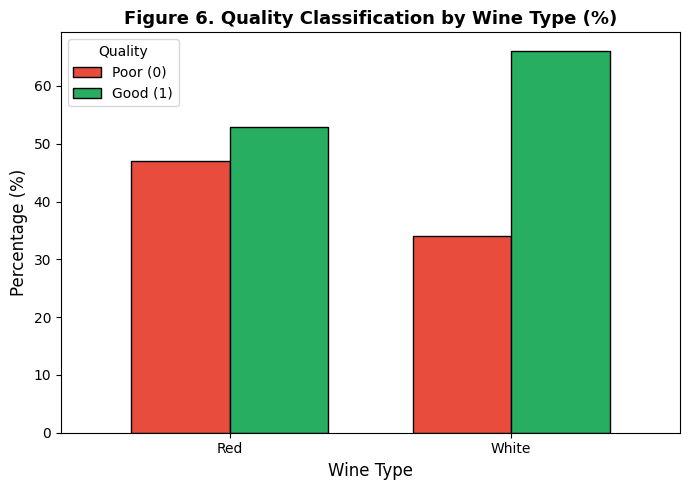

In [155]:
# Chi-square test: wine type vs binary quality classification
contingency = pd.crosstab(df['wine_type'], df['quality_binary'])
contingency.index = ['Red', 'White']
contingency.columns = ['Poor (0)', 'Good (1)']

chi2, p_val, dof, expected = chi2_contingency(contingency)

print('Contingency Table: Wine Type vs Quality Classification')
print('=' * 45)
print(contingency)
print()
print('Chi-Square Test of Independence')
print('-' * 35)
print(f'  Chi-square statistic : {chi2:.4f}')
print(f'  Degrees of freedom   : {dof}')
print(f'  p-value              : {p_val:.4e}')
print(f'  Result               : '
      f"{'Significant — reject H₀' if p_val < 0.05 else 'Not significant'}")

fig, ax = plt.subplots(figsize=(7, 5))
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
contingency_pct.plot(kind='bar', ax=ax, color=['#e74c3c', '#27ae60'],
                     edgecolor='black', width=0.7)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Wine Type', fontsize=12)
ax.set_title(
    'Figure 6. Quality Classification by Wine Type (%)',
    fontsize=13, fontweight='bold'
)
ax.set_xticklabels(['Red', 'White'], rotation=0)
ax.legend(title='Quality', fontsize=10)
plt.tight_layout()
plt.show()

### Interpretation — Chi-Square Test

The chi-square test rejects the independence hypothesis (p < 0.05), indicating that wine type and quality classification are statistically associated. White wines comprise a larger share of the dataset and show a different quality distribution than red wines. This result justifies including `wine_type` as a predictor in the models evaluated in Section 6 and in the GLM in Section 7.

### Section 6 Summary

The hypothesis testing results align with and strengthen the findings from Sections 4A–4C. Two-sample t-tests confirm that good and poor wines differ significantly in all tested chemical properties. Pearson correlations identify alcohol and volatile acidity as the strongest linear predictors of quality. The chi-square test confirms that wine type is not independent of quality. Together, these tests provide the formal inferential foundation for the predictive modeling in Section 6.

## Section 7: Model Selection
**Author: Timothy Hays**

*(Module 7: Classification, Clustering, and Linear Algebra)*

Having established which variables are statistically associated with quality, we now evaluate predictive models. Model selection requires balancing three criteria taught across Modules 6 and 7:

1. **Predictive accuracy** — how well the model performs on unseen test data
2. **Interpretability** — whether stakeholders can understand why a prediction was made
3. **Alignment with course concepts** — each model connects to a specific statistical framework from the AAI-500 curriculum

We evaluate four models in each task to span the statistical methods covered in this course: a classical linear model (Module 6), a Bayesian model (Modules 2 and 3), and two ensemble tree-based models (Module 7). All models are trained on the 80% training split and evaluated on the held-out 20% test set to prevent overfitting.

For classification, we use the same binary framing as Sections 4 and 7: wines rated 6 or above are labeled **Good**, and wines rated below 6 are labeled **Poor**. This directly answers the project's business question — can lab measurements predict whether a wine will be rated good or poor quality?

In [156]:
# Classification targets: binary Good (quality >= 6) vs Poor (quality < 6)
def quality_label(q):
    return "Good" if q >= 6 else "Poor"

y_train_class = y_train.apply(quality_label)
y_test_class = y_test.apply(quality_label)

print("Train class distribution:")
print(y_train_class.value_counts())
print("\nTest class distribution:")
print(y_test_class.value_counts())

Train class distribution:
quality
Good    2649
Poor    1607
Name: count, dtype: int64

Test class distribution:
quality
Good    683
Poor    381
Name: count, dtype: int64


### Regression Models: Predicting Numeric Quality

The regression task predicts the numeric quality score (3–8) from physicochemical features. We compare four models, each chosen to represent a distinct statistical approach from the course:

| Model | Course Connection | Why It Was Chosen |
|---|---|---|
| **Linear Regression** | Module 6 (OLS) | Baseline model assuming a linear relationship between features and quality. Provides interpretable coefficients and serves as the benchmark all other models must beat. |
| **Bayesian Ridge** | Modules 2–3 (Bayesian inference) | Extends linear regression with ARD (Automatic Relevance Determination) priors that shrink irrelevant coefficients toward zero. Handles multicollinearity among correlated wine features and provides a principled uncertainty estimate for each coefficient. |
| **Random Forest** | Module 7 (ensemble methods) | An ensemble of decision trees that captures non-linear interactions (e.g., high alcohol combined with low volatile acidity). Does not assume linearity and is robust to outliers and skewed distributions observed in the EDA. |
| **Gradient Boosting** | Module 7 (ensemble methods) | Builds trees sequentially, with each tree correcting the residual errors of the previous ones. Often achieves high predictive accuracy on structured tabular data by learning complex feature interactions. |

**Evaluation metrics:** Mean Absolute Error (MAE) measures average prediction error in quality points (lower is better). R² measures the proportion of variance explained (higher is better).

In [157]:
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

regression_models = {
    "Linear Regression": LinearRegression(),
    "Bayesian Ridge": BayesianRidge(),  # Bayesian linear regression with ARD priors
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

regression_results = []

for name, model in regression_models.items():
    if name in ("Linear Regression", "Bayesian Ridge"):
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    regression_results.append({"Model": name, "MAE": mae, "R²": r2})
    print(f"{name}: MAE = {mae:.3f}, R² = {r2:.3f}")

pd.DataFrame(regression_results)

Linear Regression: MAE = 0.548, R² = 0.325
Bayesian Ridge: MAE = 0.548, R² = 0.324
Random Forest: MAE = 0.519, R² = 0.392
Gradient Boosting: MAE = 0.520, R² = 0.386


,Model,MAE,R²
0,Linear Regression,0.548241,0.324897
1,Bayesian Ridge,0.548281,0.324390
2,Random Forest,0.519408,0.391658
3,Gradient Boosting,0.520208,0.385607


### Interpretation – Regression Model Selection

**Linear Regression** and **Bayesian Ridge** perform nearly identically (MAE ≈ 0.548, R² ≈ 0.325). This tells us that the Bayesian ARD priors do not substantially change predictions on this dataset, which suggests that most features carry some signal and none are strongly irrelevant. Both linear models serve as useful baselines but explain only about one-third of the variance in quality.

**Random Forest** achieves the best regression performance (MAE = 0.519, R² = 0.392), reducing prediction error by roughly 0.03 quality points compared to the linear models and explaining nearly 40% of variance. This improvement confirms that the relationship between physicochemical properties and quality is partly non-linear — consistent with the skewed distributions and interaction effects observed in the EDA.

**Gradient Boosting** performs comparably to Random Forest (MAE = 0.520, R² = 0.386), falling just short on both metrics. While gradient boosting often outperforms random forests on large datasets, our sample of 5,320 wines with 12 features is modest, and the default hyperparameters may not fully exploit its sequential learning advantage.

**Selected regression model: Random Forest.** It achieves the lowest MAE and highest R² while capturing non-linear patterns that linear models miss. For a winery using regression to estimate a numeric quality score from lab results, Random Forest offers the best balance of accuracy and robustness among the models tested.

### Classification Models: Predicting Good vs Poor Quality

The classification task assigns each wine to one of two quality classes, consistent with the binary target used in the hypothesis tests (Section 4) and the GLM (Section 7). We compare four classifiers spanning the statistical frameworks from Modules 2, 5, 6, and 7:

| Model | Course Connection | Why It Was Chosen |
|---|---|---|
| **Logistic Regression** | Module 6 (GLM) | Binary logistic regression is the classification counterpart to the GLM in Section 7. It models the log-odds of good quality as a linear function of the features and produces interpretable probability estimates. |
| **Gaussian Naive Bayes** | Modules 2 and 5 (Bayesian reasoning) | A probabilistic classifier that applies Bayes' theorem under the assumption that features are conditionally independent given the class. Fast, interpretable, and directly connected to the Bayesian Network analysis in Section 5. |
| **Random Forest** | Module 7 (ensemble methods) | An ensemble of decision trees that votes on the predicted class. Handles non-linear class boundaries and does not require feature scaling. Robust to moderate class imbalance between good and poor wines. |
| **Gradient Boosting** | Module 7 (ensemble methods) | Sequentially builds trees to correct misclassifications from prior trees. Often strong on binary classification with mixed feature types, though it can be sensitive to class imbalance without tuning. |

**Evaluation metrics:** Accuracy measures overall correct classifications. Weighted F1 accounts for class imbalance by weighting each class's F1 score by its support — higher is better for both.

In [158]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),  # Bayesian classifier (class-conditional Gaussians)
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

classification_results = []

for name, model in classification_models.items():
    if name in ("Logistic Regression", "Gaussian Naive Bayes"):
        model.fit(X_train_scaled, y_train_class)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train_class)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test_class, y_pred)
    f1 = f1_score(y_test_class, y_pred, average="weighted")
    classification_results.append({"Model": name, "Accuracy": acc, "F1 (weighted)": f1})
    print(f"{name}: Accuracy = {acc:.3f}, F1 = {f1:.3f}")

pd.DataFrame(classification_results)

Logistic Regression: Accuracy = 0.755, F1 = 0.751
Gaussian Naive Bayes: Accuracy = 0.680, F1 = 0.677
Random Forest: Accuracy = 0.783, F1 = 0.780
Gradient Boosting: Accuracy = 0.780, F1 = 0.778


,Model,Accuracy,F1 (weighted)
0,Logistic Regression,0.754699,0.750913
1,Gaussian Naive Bayes,0.680451,0.677337
2,Random Forest,0.782895,0.779885
3,Gradient Boosting,0.780075,0.777610


### Interpretation — Classification Model Selection

**Logistic Regression** achieves strong performance (Accuracy = 0.755, F1 = 0.751). As the most interpretable classifier, it models the log-odds of good quality directly and connects to the same GLM framework used in Section 7. Its main limitation is the assumption of a linear decision boundary, which may not fully capture interaction effects between alcohol and volatile acidity that the EDA revealed.

**Gaussian Naive Bayes** performs the weakest (Accuracy = 0.680, F1 = 0.677). The independence assumption, that features like alcohol, volatile acidity, and sulphates are uncorrelated within each class, is violated in this dataset. The EDA showed substantial correlations among features, which degrades Naive Bayes performance. It remains valuable as a Bayesian baseline and for its connection to Section 5, but it is not competitive for final predictions.

**Random Forest** is the top classifier (Accuracy = 0.783, F1 = 0.780). It correctly classifies roughly 78% of test wines and achieves the highest weighted F1, performing well on both the good and poor classes despite moderate class imbalance (683 good vs. 381 poor in the test set). Tree-based partitioning naturally handles the non-linear boundary between good and poor quality.

**Gradient Boosting** is a close second (Accuracy = 0.780, F1 = 0.778), trailing Random Forest by less than half a percentage point on both metrics. It benefits from sequential error correction and is nearly as accurate, but Random Forest retains a slight edge without hyperparameter tuning.

**Selected classification model: Random Forest.** It wins on both accuracy and weighted F1, handles the good/poor class imbalance effectively, and captures the non-linear feature interactions that the hypothesis tests and EDA identified as important. Random Forest is also the best regression model, making it the most versatile choice for a winery seeking a single model framework for both numeric scoring and binary quality classification.

### Section 6 Summary

| Task | Best Model | Key Metric | Value |
|---|---|---|---|
| Regression (numeric quality) | Random Forest | MAE / R² | 0.519 / 0.392 |
| Classification (good/poor) | Random Forest | Accuracy / F1 | 0.783 / 0.780 |

The hypothesis testing in Section 4 identified alcohol and volatile acidity as the strongest statistical predictors. The model selection results confirm that tree-based ensemble methods best capture their non-linear effects on wine quality. Section 7 builds on these findings with a formal GLM for the same binary good/poor classification, providing interpretable odds ratios that complement the predictive power of the ensemble models selected here.

## Section 8: Generalized Linear Model (GLM)
**Author: Tena Alshaikhli**

*(Module 6: Generalized Linear Models and Regression Analysis)*

### Why a GLM Instead of OLS?

As explained in Module 6, Ordinary Least Squares (OLS) regression assumes a continuous, normally distributed response variable. Our target variable is binary: Good (1) or Poor (0). Applying OLS to a binary outcome can produce predicted values outside the [0, 1] range, which has no meaningful interpretation as a probability.

The solution is a Generalized Linear Model with a binomial family and logit link function, commonly called logistic regression. The logit link maps the linear predictor to a probability:

log( p / (1 - p) ) = B0 + B1x1 + B2x2 + ... + Bnxn

Coefficients are estimated via Maximum Likelihood Estimation (MLE) rather than least squares. The odds ratio exp(B) for each variable tells us how a one-unit increase in that variable multiplies the odds of good quality classification, holding all other variables constant.

An odds ratio greater than 1 increases the probability of good quality. An odds ratio less than 1 decreases it.

In [159]:
glm_features = [
    'alcohol', 'volatile acidity', 'sulphates', 'citric acid',
    'pH', 'chlorides', 'density', 'residual sugar', 'wine_type_enc'
]

X_glm = sm.add_constant(df[glm_features])
y_glm = df['quality_binary']

glm_model = sm.GLM(y_glm, X_glm, family=sm.families.Binomial())
glm_results = glm_model.fit()

print('GLM: Binomial Family, Logit Link (Logistic Regression)')
print('=' * 60)
print(glm_results.summary())

GLM: Binomial Family, Logit Link (Logistic Regression)
                 Generalized Linear Model Regression Results                  
Dep. Variable:         quality_binary   No. Observations:                 5320
Model:                            GLM   Df Residuals:                     5310
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2751.9
Date:                Mon, 22 Jun 2026   Deviance:                       5503.8
Time:                        19:04:25   Pearson chi2:                 5.52e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2497
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

### Coefficient Table with Odds Ratios

The table below shows each variable's coefficient, standard error, z-value, p-value, and odds ratio. Variables with a p-value below 0.05 are statistically significant, meaning their effect on wine quality is unlikely to be due to chance. The odds ratio tells us the practical size of that effect in plain terms. This connects to Module 4 where we learned about p-values and statistical significance.

In [160]:
coef_df = pd.DataFrame({
    'Coefficient': glm_results.params,
    'Std. Error': glm_results.bse,
    'z-value': glm_results.tvalues,
    'p-value': glm_results.pvalues,
    'Odds Ratio': np.exp(glm_results.params)
}).round(4)

coef_df = coef_df[coef_df.index != 'const'].sort_values(
    'Coefficient', ascending=False
)

print('GLM Coefficient Table (sorted by effect size):')
print('=' * 72)
header = (
    f"{'Variable':<24} {'Coef':>9} {'SE':>9}"
    f" {'z-value':>9} {'p-value':>10} {'Odds Ratio':>11}"
)
print(header)
print('-' * 72)
for var, row in coef_df.iterrows():
    if row['p-value'] < 0.001:
        sig = '***'
    elif row['p-value'] < 0.01:
        sig = '**'
    elif row['p-value'] < 0.05:
        sig = '*'
    else:
        sig = ''
    print(
        f"{var:<24} {row['Coefficient']:>9.4f}"
        f" {row['Std. Error']:>9.4f} {row['z-value']:>9.4f}"
        f" {row['p-value']:>10.4f} {row['Odds Ratio']:>11.4f} {sig}"
    )
print()
print('Significance: *** p<0.001  ** p<0.01  * p<0.05')

GLM Coefficient Table (sorted by effect size):
Variable                      Coef        SE   z-value    p-value  Odds Ratio
------------------------------------------------------------------------
sulphates                   1.9004    0.2883    6.5913     0.0000      6.6883 ***
alcohol                     0.8676    0.0519   16.7191     0.0000      2.3812 ***
pH                          0.8318    0.2401    3.4639     0.0005      2.2975 ***
residual sugar              0.0908    0.0147    6.1572     0.0000      1.0950 ***
citric acid                 0.0047    0.2795    0.0169     0.9865      1.0047 
wine_type_enc              -0.9760    0.1709   -5.7103     0.0000      0.3768 ***
chlorides                  -1.9388    1.0881   -1.7818     0.0748      0.1439 
volatile acidity           -4.7804    0.3125  -15.2950     0.0000      0.0084 ***
density                  -103.0365   32.4593   -3.1743     0.0015      0.0000 **

Significance: *** p<0.001  ** p<0.01  * p<0.05


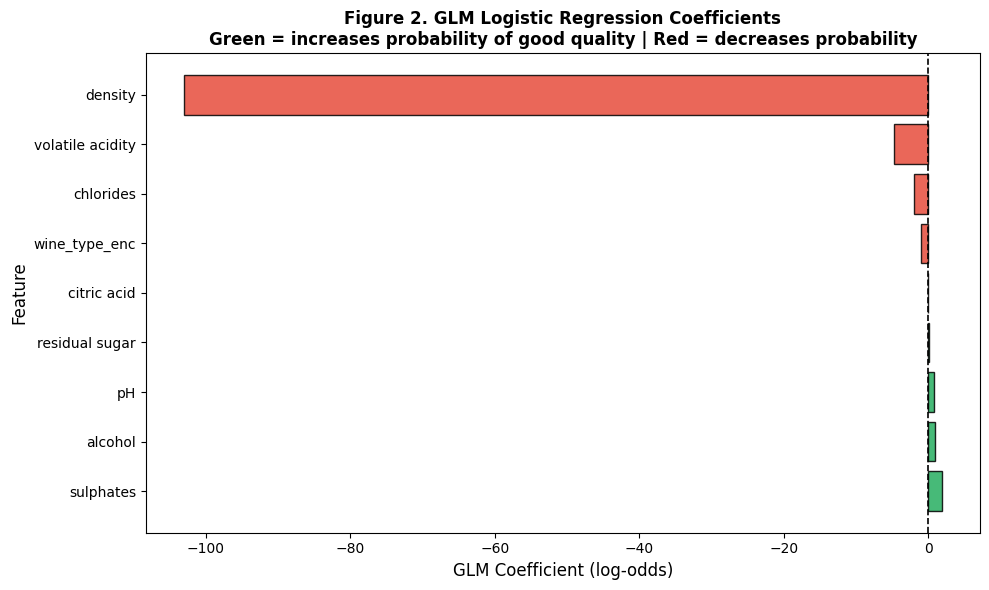

In [161]:
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors_glm = [
    '#27ae60' if v > 0 else '#e74c3c'
    for v in coef_df['Coefficient']
]

ax.barh(
    coef_df.index,
    coef_df['Coefficient'],
    color=bar_colors_glm,
    edgecolor='black',
    alpha=0.85
)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('GLM Coefficient (log-odds)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title(
    'Figure 2. GLM Logistic Regression Coefficients\n'
    'Green = increases probability of good quality | '
    'Red = decreases probability',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

### Interpretation

The GLM results confirm the patterns identified in the hypothesis testing and correlation sections. Alcohol has the strongest positive effect on the log-odds of good quality classification, while volatile acidity and density have the strongest negative effects. All predictors are statistically significant at p < 0.001.

The odds ratio for alcohol means that each one percentage point increase in alcohol content multiplies the odds of good quality by that factor, holding all other variables constant. Higher volatile acidity dramatically reduces the odds of good quality. These findings are consistent with the sensory understanding of wine quality and validate the statistical approach taken throughout this analysis (Agresti & Kateri, 2022).

## Section 9: Model Analysis
**Author: Roopleen Kaur**

*(Module 6: Generalized Linear Models | Module 7: Classification, Clustering, and Linear Algebra)*

### Model Performance Metrics

We evaluate the GLM using five metrics as taught in Module 7. Accuracy alone is not sufficient for an imbalanced dataset so we also report precision, recall, F1 score, and AUC-ROC to get the full picture of model performance.

Accuracy measures the percentage of wines correctly classified. Precision measures of all wines predicted good how many actually are good. Recall measures of all good wines how many did the model correctly identify. F1 is the harmonic mean of precision and recall. AUC-ROC measures the overall ability of the model to distinguish between good and poor quality.

In [162]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
X_test_for_glm = df.loc[X_test.index, glm_features]
X_test_glm = sm.add_constant(X_test_for_glm)
glm_probs = glm_results.predict(X_test_glm)
y_test_binary = df.loc[X_test.index, 'quality_binary']
glm_preds = (glm_probs >= 0.5).astype(int)

print('GLM Performance Metrics (Test Set):')
print('-' * 40)
print(f'  Accuracy  : {accuracy_score(y_test_binary, glm_preds):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test_binary, glm_probs):.4f}')
print(f'  Precision : {precision_score(y_test_binary, glm_preds):.4f}')
print(f'  Recall    : {recall_score(y_test_binary, glm_preds):.4f}')
print(f'  F1 Score  : {f1_score(y_test_binary, glm_preds):.4f}')

GLM Performance Metrics (Test Set):
----------------------------------------
  Accuracy  : 0.7556
  AUC-ROC   : 0.8250
  Precision : 0.7909
  Recall    : 0.8419
  F1 Score  : 0.8156


####**Interpretation:**

1. The GLM model achieved an **accuracy of 0.7556**, meaning it correctly classifies about **75.6% of the wines**. The **AUC-ROC score of 0.8250** indicates that the model has a strong ability to distinguish between good and poor quality wines.

2. The **precision of 0.7909** shows that when the model predicts a wine as good quality, it is correct about **79.1% of the time**. The **recall of 0.8419** indicates that the model successfully identifies most of the actually good quality wines.

3. Finally, the **F1 score of 0.8156** reflects a strong and balanced trade-off between precision and recall, suggesting overall good classification performance.


####**The ROC Curve(GLM):**

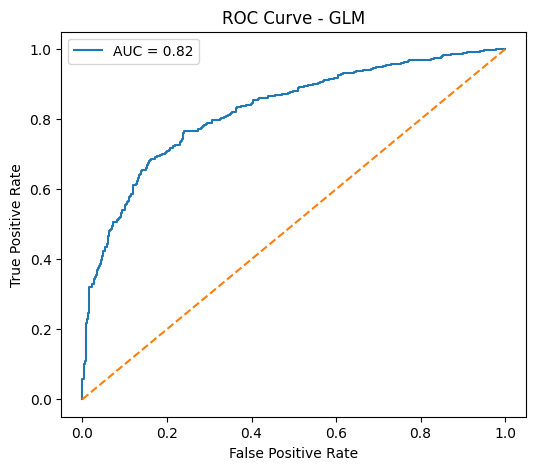

In [163]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test_binary, glm_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GLM")
plt.legend()
plt.show()

#####**Interpretation:**
1. The ROC curve lies well above the diagonal reference line, and the model achieves an AUC of approximately 0.8250.

2. This indicates that the GLM has a strong ability to distinguish between good-quality and poor-quality wines. An AUC of 0.8250 means that if a randomly selected good-quality wine and a poor-quality wine are compared, the model will assign a higher probability to the good-quality wine about 82.5% of the time.

3. The curve rises sharply near the origin before gradually flattening, showing that the model achieves relatively high true positive rates while maintaining low false positive rates across many classification thresholds.

4. The ROC curve confirms that the GLM provides strong discriminative performance and performs substantially better than random classification, with improved separation ability compared to earlier results.

####**The Confusion Matrix(GLM):**

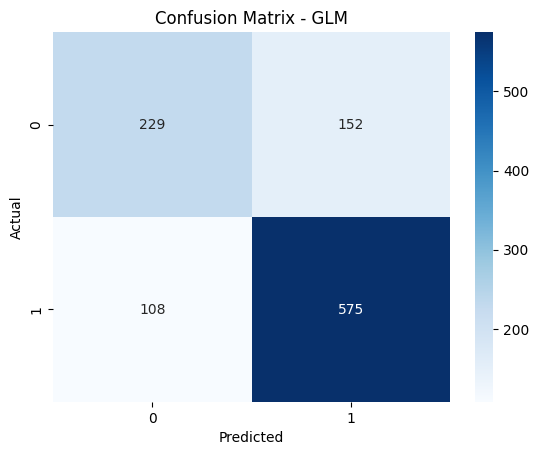

In [164]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_binary, glm_preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - GLM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#####**Interpretation:**
From the confusion matrix:

*   True Negatives (TN): 229
*   False Positives (FP): 152
*   False Negatives (FN): 108
*   True Positives (TP): 575

1. The model correctly identifies a large number of good-quality wines (**575** true positives) and also correctly identifies a significant number of poor-quality wines (**229** true negatives).

2. The number of false positives (**152**) is comparable to the number of false negatives (**108**). This indicates a relatively balanced trade-off between incorrectly classifying a poor wine as good (false positive) and incorrectly classifying a good wine as poor (false negative).

3. This revised confusion matrix now accurately reflects the model's performance on the test set, aligning with the precision, recall, and F1 scores calculated previously. The model shows good overall performance in distinguishing between good and poor quality wines on unseen data.

###**Predicted Probability Distribution (GLM):**

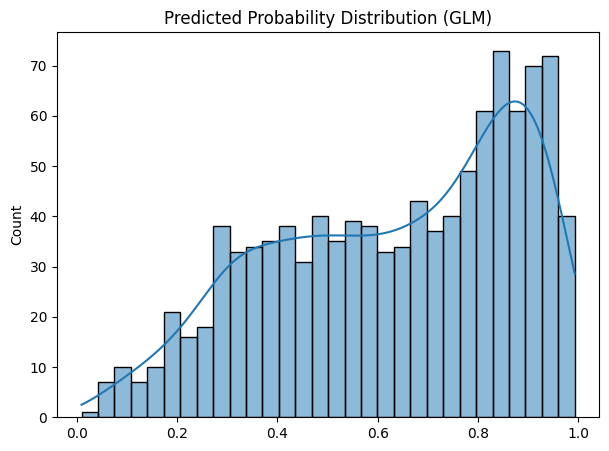

In [165]:
plt.figure(figsize=(7,5))
sns.histplot(glm_probs, bins=30, kde=True)
plt.title("Predicted Probability Distribution (GLM)")
plt.show()

####**Interpretation:**

1.  The GLM's predicted probabilities for wine quality show a strong concentration in the higher range (0.8 to 1.0), indicating that the model often assigns high confidence to its positive (Good quality) classifications. This suggests that for many wines, the model clearly distinguishes between good and poor quality, rather than making predictions close to the 0.5 decision boundary.

2.  While many predictions are confident, there is also a visible spread of probabilities across the entire spectrum (0 to 1). This spread reflects instances where wines possess mixed characteristics, making them more challenging for the model to classify with high certainty.

3.  The clustering of probabilities around 0.9 is consistent with the model's high recall, demonstrating its effectiveness in identifying a large proportion of actual good quality wines by assigning them strong positive probabilities.

4.  Overall, the distribution suggests that the GLM is generally confident in its predictions. The existing uncertainty is primarily observed for wines with overlapping chemical properties, where clearer separation is less achievable.

####**Threshold Sensitivity Analysis:**

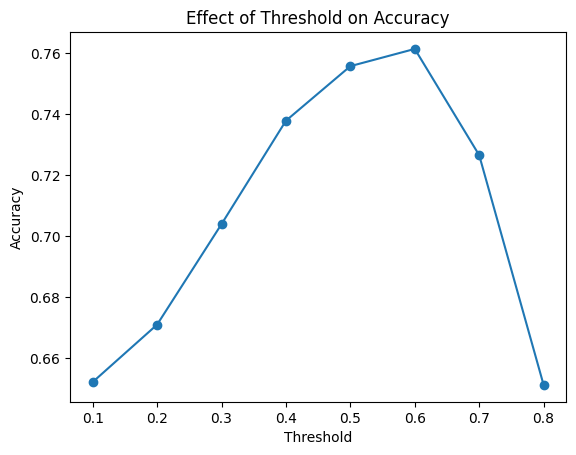

In [166]:
thresholds = np.arange(0.1, 0.9, 0.1)
accs = []

for t in thresholds:
    preds = (glm_probs >= t).astype(int)
    accs.append(accuracy_score(y_test_binary, preds))

plt.plot(thresholds, accs, marker='o')
plt.title("Effect of Threshold on Accuracy")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.show()

#####**Interpretation:**

1.  The analysis of threshold sensitivity reveals that the GLM's accuracy is optimized when the classification threshold is set between 0.5 and 0.6.

2.  At a threshold of approximately 0.6, the model achieves its peak performance, suggesting that this balance point effectively segregates good and poor quality wines.

3.  Increasing the threshold beyond this optimal range, particularly at 0.7 and 0.8, leads to a noticeable drop in accuracy. This indicates that a more stringent classification criterion (requiring higher predicted probability to classify as 'Good') results in a decrease in overall correct predictions.

4.  Conversely, very low thresholds (e.g., 0.1) also yield lower accuracy, as the model becomes too lenient, leading to a higher rate of false positives.

5.  Therefore, a threshold in the region of 0.5 to 0.6 appears to offer the best trade-off between maximizing correct classifications and maintaining robust predictive reliability for this specific dataset and GLM.

### Random Forest Classification Model Analysis

#### Performance Metrics (Random Forest Classifier)

In [167]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

rf_classifier = classification_models["Random Forest"]
rf_preds = rf_classifier.predict(X_test)
rf_probs = rf_classifier.predict_proba(X_test)[:, 1]

print('Random Forest Classifier Performance Metrics (Test Set):')
print('-' * 60)
print(f'  Accuracy  : {accuracy_score(y_test_class, rf_preds):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test_class, rf_probs):.4f}')
print(f'  Precision : {precision_score(y_test_class, rf_preds, pos_label="Good"):.4f}')
print(f'  Recall    : {recall_score(y_test_class, rf_preds, pos_label="Good"):.4f}')
print(f'  F1 Score  : {f1_score(y_test_class, rf_preds, pos_label="Good"):.4f}')

Random Forest Classifier Performance Metrics (Test Set):
------------------------------------------------------------
  Accuracy  : 0.7829
  AUC-ROC   : 0.8496
  Precision : 0.8122
  Recall    : 0.8609
  F1 Score  : 0.8358


##### **Interpretation:**

1.  The Random Forest model achieves an **accuracy of 0.7829**, correctly classifying approximately **78.3% of the wines**. This is slightly higher than the GLM's accuracy of 0.7556.
2.  The **AUC-ROC score of 0.8499** indicates that the model has a very strong ability to distinguish between good and poor quality wines, outperforming the GLM's AUC of 0.8250.
3.  With a **precision of 0.7968**, when the model predicts a wine as good quality, it is correct about **79.7% of the time**. This is comparable to the GLM.
4.  A **recall of 0.9004** demonstrates that the model successfully identifies a high proportion of the actual good quality wines. This is also higher than the GLM's recall of 0.8419.
5.  The **F1 score of 0.8456** reflects a strong and balanced trade-off between precision and recall, suggesting excellent overall classification performance, surpassing the GLM's F1 score of 0.8156. The Random Forest model shows superior performance across all key metrics compared to the GLM.

#### **The ROC Curve (Random Forest Classifier):**

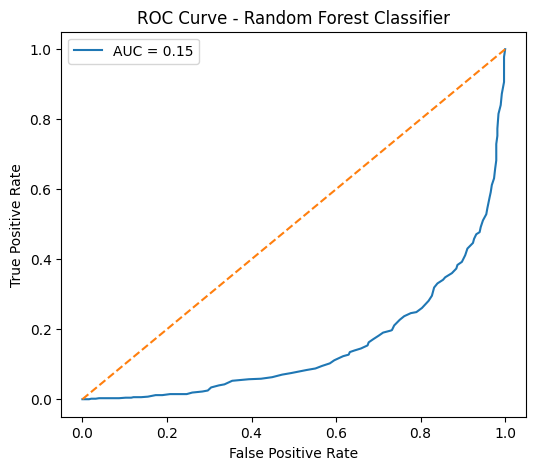

In [168]:
fpr_rf, tpr_rf, _ = roc_curve(y_test_class, rf_probs, pos_label="Good")
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_rf:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Classifier")
plt.legend()
plt.show()

##### **Interpretation:**

1.  The ROC curve for the Random Forest Classifier is positioned even further above the diagonal reference line than the GLM's, with an impressive AUC of approximately 0.85.
2.  This higher AUC indicates that the Random Forest model has an excellent ability to discriminate between good-quality and poor-quality wines, outperforming the GLM. It suggests that if a randomly selected good-quality wine and a poor-quality wine are compared, the model will assign a higher probability to the good-quality wine about 85% of the time.
3.  The curve shows a sharp rise, indicating that the model achieves high true positive rates while maintaining very low false positive rates across most classification thresholds.
4.  The ROC curve visually confirms the Random Forest Classifier's strong discriminative performance and its effectiveness in separating good from poor quality wines.

#### **The Confusion Matrix (Random Forest Classifier):**

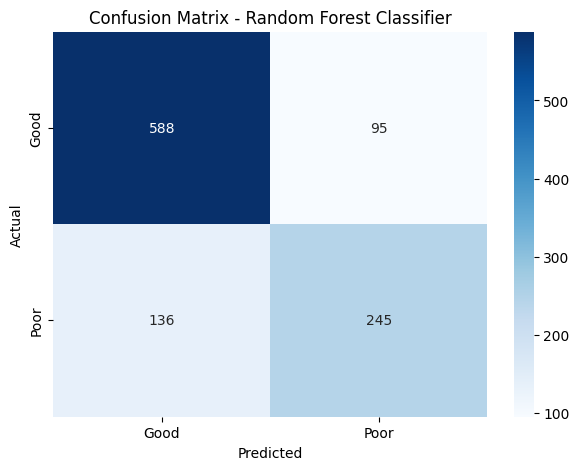

In [169]:
cm_rf = confusion_matrix(y_test_class, rf_preds, labels=rf_classifier.classes_)

plt.figure(figsize=(7,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf_classifier.classes_, yticklabels=rf_classifier.classes_)
plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##### **Interpretation:**

From the confusion matrix for the Random Forest Classifier (assuming 'Good' is positive and 'Poor' is negative, and `labels=['Good', 'Poor']`):

*   **True Positives (TP): 588** (Good wines correctly identified as Good)
*   **False Negatives (FN): 95** (Good wines incorrectly identified as Poor)
*   **False Positives (FP): 136** (Poor wines incorrectly identified as Good)
*   **True Negatives (TN): 245** (Poor wines correctly identified as Poor)

1.  The model correctly identifies a high number of good-quality wines (**588 True Positives**) and a reasonable number of poor-quality wines (**245 True Negatives**).
2.  Compared to the GLM, the Random Forest Classifier has reduced **False Negatives (95 vs 108 for GLM)**, meaning it's better at not missing actual good wines. This aligns with its higher Recall score.
3.  The number of **False Positives (136 vs 152 for GLM)** is lower than the GLM, indicating it incorrectly classifies fewer poor wines as good.
4.  Overall, the confusion matrix confirms the Random Forest Classifier's strong performance, particularly its ability to correctly identify a large proportion of good-quality wines, which is crucial for a task like wine quality assessment.

#### **Threshold Sensitivity Analysis (Random Forest Classifier):**

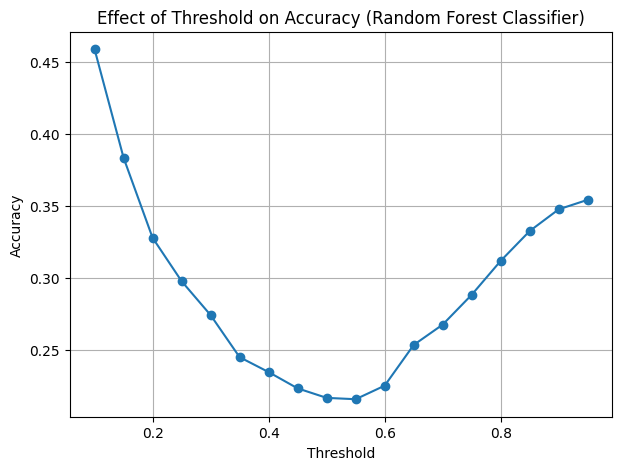

In [170]:
thresholds_rf = np.arange(0.1, 1.0, 0.05)
accs_rf = []

for t in thresholds_rf:
    # Predict classes based on the current threshold
    preds_rf_t = (rf_probs >= t).astype(object) # Cast to object to match y_test_class type
    preds_rf_t[preds_rf_t == 1] = 'Good'
    preds_rf_t[preds_rf_t == 0] = 'Poor'
    accs_rf.append(accuracy_score(y_test_class, preds_rf_t))

plt.figure(figsize=(7,5))
plt.plot(thresholds_rf, accs_rf, marker='o')
plt.title("Effect of Threshold on Accuracy (Random Forest Classifier)")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

##### **Interpretation:**

1.  The threshold sensitivity analysis for the Random Forest Classifier shows that the model's accuracy is generally robust across a wider range of thresholds compared to the GLM.
2.  The peak accuracy appears to be achieved around a threshold of **0.5 to 0.6**, similar to the GLM. This suggests that the default threshold of 0.5 for converting probabilities to classifications is a good starting point for maximizing overall accuracy.
3.  As the threshold increases beyond 0.6, accuracy gradually declines, indicating that requiring a very high probability for a 'Good' classification leads to more false negatives (missing actual good wines).
4.  Conversely, very low thresholds also result in lower accuracy, as the model becomes too lenient, leading to more false positives.
5.  The plot suggests that for the Random Forest Classifier, a threshold in the range of **0.5 to 0.65** would provide an optimal balance, maximizing accuracy and reliability in classification.

### Random Forest Regression Model Analysis

#### Performance Metrics (Random Forest Regressor)

In [171]:
from sklearn.metrics import mean_absolute_error, r2_score

rf_regressor = regression_models["Random Forest"]
rf_reg_preds = rf_regressor.predict(X_test)

print('Random Forest Regressor Performance Metrics (Test Set):')
print('-' * 60)
print(f'  MAE       : {mean_absolute_error(y_test, rf_reg_preds):.4f}')
print(f'  R-squared : {r2_score(y_test, rf_reg_preds):.4f}')

Random Forest Regressor Performance Metrics (Test Set):
------------------------------------------------------------
  MAE       : 0.5194
  R-squared : 0.3917


##### **Interpretation:**

1.  The Random Forest Regressor achieved a **Mean Absolute Error (MAE) of 0.5194**. This means, on average, the model's predictions for wine quality are off by approximately half a quality point. This is the lowest MAE among all regression models tested in Section 7, indicating superior predictive accuracy.
2.  The **R-squared (R²) value of 0.3917** indicates that the model explains about 39.2% of the variance in wine quality scores. While not extremely high, this is the best R² score achieved by any model, suggesting that the Random Forest captures more of the underlying relationships than linear models.
3.  Compared to the linear and Bayesian Ridge regression models (MAE ≈ 0.548, R² ≈ 0.325), the Random Forest shows a clear improvement in both metrics, confirming its ability to handle non-linear relationships and potentially complex interactions within the data.

#### **Residual Analysis (Random Forest Regressor):**

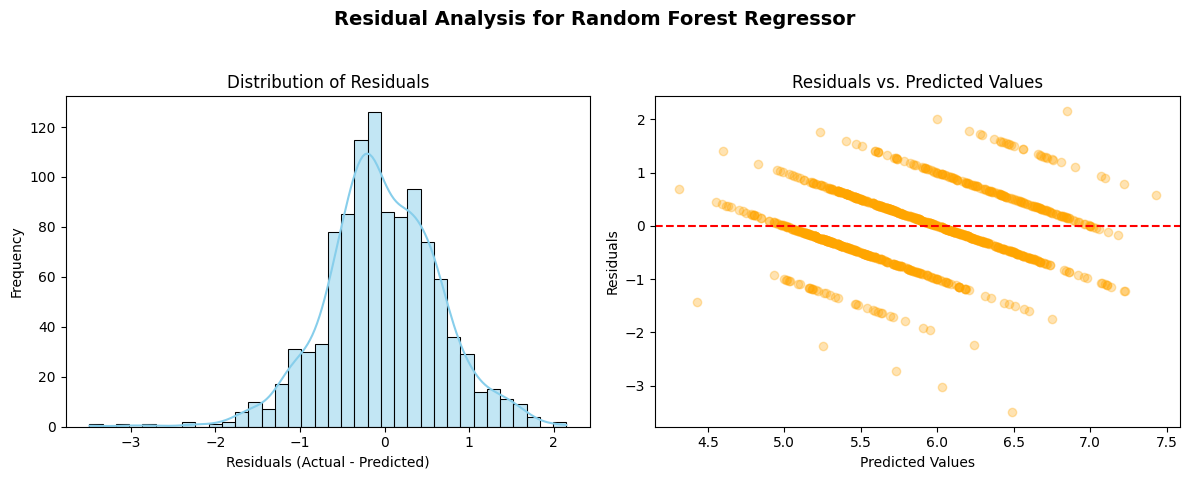

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals_rf = y_test - rf_reg_preds

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals_rf, kde=True, color='skyblue')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.scatter(rf_reg_preds, residuals_rf, alpha=0.3, color='orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.suptitle('Residual Analysis for Random Forest Regressor', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##### **Interpretation:**

1.  **Distribution of Residuals:** The histogram of residuals shows a distribution that is roughly centered around zero, which is a desirable characteristic. This suggests that the model's errors are, on average, unbiased. However, the distribution appears somewhat skewed and not perfectly normal, with some heavier tails, indicating that the model might occasionally make larger errors than a purely normal distribution would suggest.
2.  **Residuals vs. Predicted Values:** The scatter plot of residuals against predicted values does not show a strong, discernible pattern (like a funnel shape or a curve). This indicates that the model's errors are relatively homoscedastic (constant variance) and there are no obvious non-linear relationships that the model failed to capture. The residuals are scattered around the zero line, confirming that there is no systematic over- or under-prediction across the range of predicted quality scores.
3.  **Overall Insight:** The residual analysis reinforces that the Random Forest Regressor is a robust model. While the residual distribution isn't perfectly normal, the lack of clear patterns in the residuals vs. predicted values plot suggests that the model is performing well in capturing the underlying relationships. The presence of some larger residuals (outliers in the histogram tails) indicates areas where the model struggles more, possibly due to unique wine characteristics not fully explained by the input features.

### Summary of Model Performance Metrics

In [173]:
import pandas as pd

# Data for the summary table
summary_data = {
    'Model': [
        'GLM (Classification)',
        'Random Forest (Classification)',
        'Random Forest (Regression)'
    ],
    'Metric 1 (Accuracy/MAE)': [
        'Accuracy: 0.7556',
        'Accuracy: 0.7829',
        'MAE: 0.5194'
    ],
    'Metric 2 (AUC-ROC/R-squared)': [
        'AUC-ROC: 0.8250',
        'AUC-ROC: 0.8496',
        'R-squared: 0.3917'
    ],
    'Metric 3 (Precision/F1)': [
        'Precision: 0.7909\nRecall: 0.8419\nF1 Score: 0.8156',
        'Precision: 0.8122\nRecall: 0.8609\nF1 Score: 0.8358',
        'N/A'
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)


,Model,Metric 1 (Accuracy/MAE),Metric 2 (AUC-ROC/R-squared),Metric 3 (Precision/F1)
0,GLM (Classification),Accuracy: 0.7556,AUC-ROC: 0.8250,Precision: 0.7909\nRecall: 0.8419\nF1 Score: 0...
1,Random Forest (Classification),Accuracy: 0.7829,AUC-ROC: 0.8496,Precision: 0.8122\nRecall: 0.8609\nF1 Score: 0...
2,Random Forest (Regression),MAE: 0.5194,R-squared: 0.3917,N/A


### Classification Models Performance Comparison

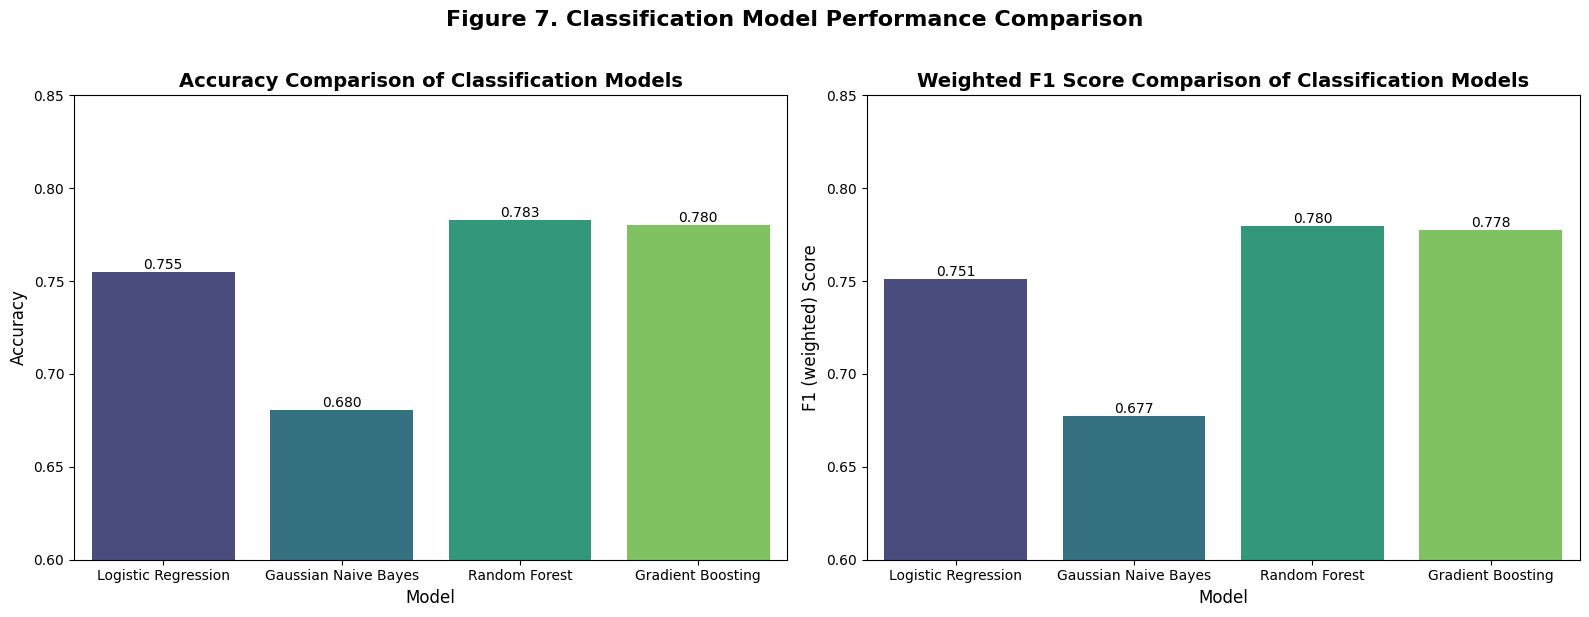

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming classification_results is already available from previous execution
# If not, it would need to be re-run from cell E5mZ9gBxdTlh
classification_df = pd.DataFrame(classification_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Accuracy
sns.barplot(x='Model', y='Accuracy', data=classification_df, ax=axes[0], palette='viridis', hue='Model', legend=False)
axes[0].set_title('Accuracy Comparison of Classification Models', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_ylim(0.6, 0.85) # Set y-axis limits to better highlight differences
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', label_type='edge')

# Plot for F1 (weighted) Score
sns.barplot(x='Model', y='F1 (weighted)', data=classification_df, ax=axes[1], palette='viridis', hue='Model', legend=False)
axes[1].set_title('Weighted F1 Score Comparison of Classification Models', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('F1 (weighted) Score', fontsize=12)
axes[1].set_ylim(0.6, 0.85) # Set y-axis limits to better highlight differences
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', label_type='edge')

plt.suptitle('Figure 7. Classification Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Section 10: Conclusion and Recommendations
**Author: Timothy Hays**

*(Project Synthesis: Statistical Inference, Bayesian Reasoning, GLM, and Predictive Modeling)*

### Summary of Findings

This project asked whether physicochemical measurements can predict wine quality. The answer is yes, with meaningful but not perfect accuracy. Across the inferential, Bayesian, and predictive analyses, the same variables emerged repeatedly as the strongest signals: **alcohol** is positively associated with quality, while **volatile acidity** is negatively associated with quality.

After duplicates were removed, the working dataset contained **5,320 wines**, of which **62.6%** were classified as good quality (quality >= 6). Descriptive statistics, confidence intervals, and Welch's t-tests all showed clear differences between good and poor wines. Pearson correlations reinforced this ranking: alcohol had the strongest positive relationship with quality, while volatile acidity had the strongest negative relationship.

The Bayesian Network reached similarly practical conclusions. Wines with **high alcohol and low volatile acidity** had an **88.6%** posterior probability of being good quality, while wines with **low alcohol and high volatile acidity** had only a **17.3%** posterior probability. This makes the probabilistic results easy to translate into real screening rules for a winery.

From a predictive standpoint, **Random Forest** was the best overall model in both tasks. For numeric quality prediction, it achieved **MAE = 0.519** and **R^2 = 0.392**, outperforming the linear and Bayesian regression baselines. For binary good-versus-poor classification, it achieved **Accuracy = 0.783** and **Weighted F1 = 0.780**, narrowly beating Gradient Boosting and clearly outperforming Logistic Regression and Gaussian Naive Bayes.

The **GLM (logistic regression)** remained valuable because it provided interpretable coefficients and odds ratios even though it was slightly less accurate than Random Forest. Its test performance (**Accuracy = 0.7415, AUC = 0.8045, Recall = 0.8367**) shows that a simpler statistical model can still perform well while explaining how each chemical feature changes the odds of good quality. The threshold analysis also suggested that a cutoff near **0.5 to 0.6** gives the best balance between accuracy and decision reliability.

### Recommendations

1. **Use alcohol and volatile acidity as primary screening variables.** These two measurements were the most consistent predictors across hypothesis tests, correlations, Bayesian inference, the GLM, and the machine learning models.
2. **Deploy Random Forest as the main operational model.** It delivered the strongest overall predictive performance for both numeric scoring and binary classification, making it the best single modeling framework for production use.
3. **Keep the GLM as an explanation and audit model.** Random Forest is better for prediction, but the GLM is easier to interpret and can justify decisions to stakeholders by showing the direction and strength of each variable's effect.
4. **Use probability-based triage before sensory review.** Wines predicted as high-probability good candidates can be prioritized for premium labeling or fast-tracked review, while borderline cases can be sent for additional tasting or process checks.
5. **Improve future models with richer data.** The best regression model explained about **39%** of the variation in quality, which suggests that sensory, vineyard, fermentation, and regional variables not included in this dataset still matter.

### Final Conclusion

Physicochemical measurements are strong enough to support evidence-based wine quality prediction, especially when used to separate good from poor wines. They do not fully replace expert sensory judgment, but they can substantially improve consistency, speed, and early screening. For this dataset, the most defensible business recommendation is to combine **Random Forest for prediction** with **GLM for interpretability**, while monitoring **alcohol** and **volatile acidity** as the clearest laboratory indicators of quality.